# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import the libraries you will be using for analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Try loading one file

df = pd.read_parquet('/content/drive/MyDrive/Assignments/2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [6]:
df.shape

(3041714, 19)

In [7]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [8]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/Assignments')

# Check if 2023.csv file is already created in the previous runs. If yes delete and create a fresh one
file_path = "2023.csv"

if os.path.exists(file_path):
    os.remove(file_path)

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        monthly_data = pd.read_parquet(file_path)

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date

        for pickup_date, date_group in monthly_data.groupby(monthly_data['tpep_pickup_datetime'].dt.date):
            for pickup_hour, hour_group in date_group.groupby(date_group['tpep_pickup_datetime'].dt.hour):
                # Sample 3% of the hourly data randomly
                sampled_hour = hour_group.sample(frac=0.03, random_state=42)

                # add data of this hour to the dataframe
                sampled_data = pd.concat([sampled_data, sampled_hour], ignore_index=True)

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data], ignore_index=True)

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137823 entries, 0 to 1137822
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   VendorID               1137823 non-null  int64         
 1   tpep_pickup_datetime   1137823 non-null  datetime64[us]
 2   tpep_dropoff_datetime  1137823 non-null  datetime64[us]
 3   passenger_count        1099193 non-null  float64       
 4   trip_distance          1137823 non-null  float64       
 5   RatecodeID             1099193 non-null  float64       
 6   store_and_fwd_flag     1099193 non-null  object        
 7   PULocationID           1137823 non-null  int64         
 8   DOLocationID           1137823 non-null  int64         
 9   payment_type           1137823 non-null  int64         
 10  fare_amount            1137823 non-null  float64       
 11  extra                  1137823 non-null  float64       
 12  mta_tax                11378

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [11]:
# Store the df in csv/parquet

df.to_csv('2023.csv')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [12]:
# Load the new data file

df = pd.read_csv('2023.csv')

In [13]:
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1.0,0.86,1.0,N,141,140,...,6.5,1.0,0.5,2.00,0.0,1.0,13.50,2.5,0.00,NaN
1,1,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,...,32.4,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
2,2,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,...,7.9,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
3,3,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,...,11.4,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
4,4,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,...,6.5,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137823 entries, 0 to 1137822
Data columns (total 21 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1137823 non-null  int64  
 1   VendorID               1137823 non-null  int64  
 2   tpep_pickup_datetime   1137823 non-null  object 
 3   tpep_dropoff_datetime  1137823 non-null  object 
 4   passenger_count        1099193 non-null  float64
 5   trip_distance          1137823 non-null  float64
 6   RatecodeID             1099193 non-null  float64
 7   store_and_fwd_flag     1099193 non-null  object 
 8   PULocationID           1137823 non-null  int64  
 9   DOLocationID           1137823 non-null  int64  
 10  payment_type           1137823 non-null  int64  
 11  fare_amount            1137823 non-null  float64
 12  extra                  1137823 non-null  float64
 13  mta_tax                1137823 non-null  float64
 14  tip_amount        

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [15]:
# Fix the index and drop any columns that are not needed
#Fix datatypes of date column
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Drop unnecessary columns
df.drop(columns=["Unnamed: 0"], errors='ignore', inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137823 entries, 0 to 1137822
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   VendorID               1137823 non-null  int64         
 1   tpep_pickup_datetime   1137823 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  1137823 non-null  datetime64[ns]
 3   passenger_count        1099193 non-null  float64       
 4   trip_distance          1137823 non-null  float64       
 5   RatecodeID             1099193 non-null  float64       
 6   store_and_fwd_flag     1099193 non-null  object        
 7   PULocationID           1137823 non-null  int64         
 8   DOLocationID           1137823 non-null  int64         
 9   payment_type           1137823 non-null  int64         
 10  fare_amount            1137823 non-null  float64       
 11  extra                  1137823 non-null  float64       
 12  mta_tax                11378

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [16]:
# Combine the two airport fee columns
if 'Airport Fee' in df.columns:
    df["airport_fee"] = df["Airport_fee"].combine_first(df["airport_fee"])

# Drop one airport fee column
df.drop(columns=["Airport_fee"], errors='ignore', inplace=True)

#Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r'[^a-z0-9]+', '_', regex=True)
      .str.strip('_')
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137823 entries, 0 to 1137822
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   vendorid               1137823 non-null  int64         
 1   tpep_pickup_datetime   1137823 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  1137823 non-null  datetime64[ns]
 3   passenger_count        1099193 non-null  float64       
 4   trip_distance          1137823 non-null  float64       
 5   ratecodeid             1099193 non-null  float64       
 6   store_and_fwd_flag     1099193 non-null  object        
 7   pulocationid           1137823 non-null  int64         
 8   dolocationid           1137823 non-null  int64         
 9   payment_type           1137823 non-null  int64         
 10  fare_amount            1137823 non-null  float64       
 11  extra                  1137823 non-null  float64       
 12  mta_tax                11378

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [17]:
# check where values of fare amount are negative
negative_fares = df[df['fare_amount'] < 0]

print("Count of negative fares:", len(negative_fares))
negative_fares[['fare_amount', 'total_amount']].head()


Count of negative fares: 0


,fare_amount,total_amount


Did you notice something different in the `RatecodeID` column for above records?

In [18]:
# Analyse RatecodeID for the negative fare amounts

negative_fares = df[df['fare_amount'] < 0]

negative_fares['ratecodeid'].value_counts(dropna=False)

,count
ratecodeid,


In [19]:
# Find which columns have negative values

# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Count negative values per column
negative_counts = (numeric_df < 0).sum()

# Print columns which have negative counts
print(negative_counts[negative_counts > 0])

extra                     3
mta_tax                  47
improvement_surcharge    50
total_amount             50
congestion_surcharge     38
airport_fee               1
dtype: int64


In [20]:
# fix these negative values

# Analyze the negative values
print(f"Unique values in column extra: ", df['extra'].unique())
print(f"Unique values in column mta_tax: ", df['mta_tax'].unique())
print(f"Unique values in column improvement_surcharge: ", df['improvement_surcharge'].unique())
print(f"Unique values in column total_amount: ", df['total_amount'].unique())
print(f"Unique values in column congestion_surcharge: ", df['congestion_surcharge'].unique())
print(f"Unique values in column airport_fee: ", df['airport_fee'].unique())

# Negative values appear to be actual values but typed wrongly with negative symbol. So it would be apt to convert it to positive value, instead of making it to 0
df["extra"] = df["extra"].abs()
df["mta_tax"] = df["mta_tax"].abs()
df["improvement_surcharge"] = df["improvement_surcharge"].abs()
df["total_amount"] = df["total_amount"].abs()
df["congestion_surcharge"] = df["congestion_surcharge"].abs()
df["airport_fee"] = df["airport_fee"].abs()

# Check if all negative values are fixed
print("---------- Check if there are any pending negative values---------------")
numeric_df = df.select_dtypes(include='number')

# Count negative values per column
negative_counts = (numeric_df < 0).sum()

print(negative_counts)


Unique values in column extra:  [ 1.    6.    0.    3.5   3.75  3.    0.5   8.5   2.25  2.5   1.25  5.
  7.5   6.25  8.75  7.25  9.75 10.   11.25  2.72  6.8   3.05  4.5   0.03
  3.2   4.75  0.7  13.75  1.5   2.75  4.25  1.75  9.25  6.75 11.75 10.25
  7.75  5.25  3.25  0.75  0.25  1.05  4.05 20.8  12.5   2.45 14.25  2.
  0.19 -1.    8.2  -2.5   2.2 ]
Unique values in column mta_tax:  [ 0.5   0.    0.8  -0.5   0.3   4.    0.05  2.5   3.5 ]
Unique values in column improvement_surcharge:  [ 1.   0.3  0.  -1. ]
Unique values in column total_amount:  [13.5  41.15 15.48 ... 12.16  6.29  8.37]
Unique values in column congestion_surcharge:  [ 2.5  0.   nan -2.5  0.5]
Unique values in column airport_fee:  [ 0.    1.25   nan -1.25]
---------- Check if there are any pending negative values---------------
vendorid                 0
passenger_count          0
trip_distance            0
ratecodeid               0
pulocationid             0
dolocationid             0
payment_type             0
fare_am

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [21]:
# Find the proportion of missing values in each column
columns_missing_vals = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

print(f"Missing values percentage for each column: \n\n", columns_missing_vals, "\n\n")

# Columns with missing values
print(f"Columns with missing values: \n\n", columns_missing_vals[columns_missing_vals > 0])

Missing values percentage for each column: 

 airport_fee              92.16996
passenger_count           3.39508
store_and_fwd_flag        3.39508
congestion_surcharge      3.39508
ratecodeid                3.39508
vendorid                  0.00000
tpep_pickup_datetime      0.00000
tpep_dropoff_datetime     0.00000
dolocationid              0.00000
pulocationid              0.00000
trip_distance             0.00000
fare_amount               0.00000
payment_type              0.00000
extra                     0.00000
mta_tax                   0.00000
tolls_amount              0.00000
tip_amount                0.00000
total_amount              0.00000
improvement_surcharge     0.00000
dtype: float64 


Columns with missing values: 

 airport_fee             92.16996
passenger_count          3.39508
store_and_fwd_flag       3.39508
congestion_surcharge     3.39508
ratecodeid               3.39508
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [22]:
# Handle passenger_count with zero value
import numpy as np

# Replace zero values with Nan
df['passenger_count'] = df['passenger_count'].replace(0.0, np.nan)

# Display the rows with null values
df[df['passenger_count'].isnull()]

# Impute NaN values in 'passenger_count'
df['passenger_count'] = df['passenger_count'].fillna(
    df['passenger_count'].median()
)

df['passenger_count'] = df['passenger_count'].astype('int64')

print(f"Final count: \n\n", df['passenger_count'].value_counts())



Final count: 

 passenger_count
1    883611
2    166057
3     41296
4     22998
5     14296
6      9551
8         7
7         4
9         3
Name: count, dtype: int64


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [23]:
# Fix missing values in 'RatecodeID'

# Find count of missing values
print(f"Count of missing values: \n", df['ratecodeid'].isnull().sum(), "\n\n")
print(f"Count of each value before fixing: \n", df['ratecodeid'].value_counts(), "\n\n")

# Fix missing values now and handle the outlier 99.0 later
df['ratecodeid'] = df['ratecodeid'].fillna(df['ratecodeid'].median())

df['ratecodeid'] = df['ratecodeid'].astype('int64')

print(f"Final count: \n", df['ratecodeid'].value_counts())

Count of missing values: 
 38630 


Count of each value before fixing: 
 ratecodeid
1.0     1037772
2.0       42974
99.0       6352
5.0        6189
3.0        3653
4.0        2251
6.0           2
Name: count, dtype: int64 


Final count: 
 ratecodeid
1     1076402
2       42974
99       6352
5        6189
3        3653
4        2251
6           2
Name: count, dtype: int64


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [24]:
# handle null values in congestion_surcharge

# Find count of missing values
print(f"Count of missing values: \n", df['congestion_surcharge'].isnull().sum(), "\n\n")
print(f"Count of each value before fixing: \n", df['congestion_surcharge'].value_counts(), "\n\n")

# Consider missing values as no surcharge as operator would have left the value blank as there is no surcharge. Setting it to 0
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)

print(f"Final count: \n", df['congestion_surcharge'].value_counts())

Count of missing values: 
 38630 


Count of each value before fixing: 
 congestion_surcharge
2.5    1014734
0.0      84458
0.5          1
Name: count, dtype: int64 


Final count: 
 congestion_surcharge
2.5    1014734
0.0     123088
0.5          1
Name: count, dtype: int64


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [25]:
# Handle any remaining missing values

columns_missing_vals = (
    df.isnull().sum()
).sort_values(ascending=False)

# Columns with missing values
print(f"Columns with missing values: \n\n", columns_missing_vals[columns_missing_vals > 0], "\n\n")

# Fix the missing value for the remaining columns store_and_fwd_flag and airport_fee

# Fix the missing value for store_and_fwd_flag. Since this is a categorical field, update field with most frequent value
print(f"Count of missing values for store_and_fwd_flag: \n", df['store_and_fwd_flag'].isnull().sum(), "\n\n")
print(f"Count of each value before fixing for store_and_fwd_flag: \n", df['store_and_fwd_flag'].value_counts(), "\n\n")
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(
    df['store_and_fwd_flag'].mode()[0]
)
print(f"Final count of store_and_fwd_flag: \n", df['store_and_fwd_flag'].value_counts())

# Fix the missing value for airport_fee. Missing value indicates no fee charged at the airport. Set it to 0.00
print(f"Count of missing values for airport_fee: \n", df['airport_fee'].isnull().sum(), "\n\n")
print(f"Count of each value before fixing for airport_fee: \n", df['airport_fee'].value_counts(), "\n\n")
df['airport_fee'] = df['airport_fee'].fillna(0.0)
print(f"Final count of airport_fee: \n", df['airport_fee'].value_counts(), "\n\n")


# Check if all the missing values are fixed
if columns_missing_vals[columns_missing_vals > 0].empty:
  print("All missing values are fixed")
else:
  print("There are still missing values !!", columns_missing_vals[columns_missing_vals > 0])


Columns with missing values: 

 airport_fee           1048731
store_and_fwd_flag      38630
dtype: int64 


Count of missing values for store_and_fwd_flag: 
 38630 


Count of each value before fixing for store_and_fwd_flag: 
 store_and_fwd_flag
N    1092456
Y       6737
Name: count, dtype: int64 


Final count of store_and_fwd_flag: 
 store_and_fwd_flag
N    1131086
Y       6737
Name: count, dtype: int64
Count of missing values for airport_fee: 
 1048731 


Count of each value before fixing for airport_fee: 
 airport_fee
0.00    81270
1.25     7822
Name: count, dtype: int64 


Final count of airport_fee: 
 airport_fee
0.00    1130001
1.25       7822
Name: count, dtype: int64 


There are still missing values !! airport_fee           1048731
store_and_fwd_flag      38630
dtype: int64


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [26]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

df.describe().T


,count,mean,min,25%,50%,75%,max,std
vendorid,1137823.0,1.733028,1.0,1.0,2.0,2.0,6.0,0.447886
tpep_pickup_datetime,1137823,2023-07-02 19:58:30.528635904,2022-12-31 23:51:30,2023-04-02 16:11:47,2023-06-27 15:48:03,2023-10-06 19:35:34,2023-12-31 23:57:51,NaN
tpep_dropoff_datetime,1137823,2023-07-02 20:15:55.574536192,2022-12-31 23:56:06,2023-04-02 16:29:53.500000,2023-06-27 16:02:28,2023-10-06 19:51:48,2024-01-01 20:14:57,NaN
passenger_count,1137823.0,1.37148,1.0,1.0,1.0,1.0,9.0,0.864008
trip_distance,1137823.0,3.70815,0.0,1.05,1.79,3.4,34804.51,74.669336
ratecodeid,1137823.0,1.618985,1.0,1.0,1.0,1.0,99.0,7.306681
pulocationid,1137823.0,165.266713,1.0,132.0,162.0,234.0,265.0,64.01098
dolocationid,1137823.0,164.011227,1.0,114.0,162.0,234.0,265.0,69.820743
payment_type,1137823.0,1.163993,0.0,1.0,1.0,1.0,4.0,0.507455
fare_amount,1137823.0,19.960081,0.0,9.3,13.5,21.9,143163.45,135.419


In [27]:
# Potential outliers and details

# 1. passenger_count has outliers.
print(f"Values for passenger_count: \n", df["passenger_count"].value_counts(), "\n\n")
# Outlier analyis: Looking at the data passenger count greater than 6 are outliers(7,8,9)

# 2. trip_distance has outliers.
print(f"Values for trip_distance: \n", df["trip_distance"].value_counts(), "\n\n")
print(f"Trips with trip_distance more than 250 miles", len(df[df['trip_distance'] > 250]), "\n\n")
# Outlier analyis: Trips with trip_distance more than 250 miles are 22

# 3. ratecodeid.
print(f"Values for ratecodeid: \n", df["ratecodeid"].value_counts(), "\n\n")
# Outlier analyis: Invalid value 99.0

# 4. Payment_type.
print(f"Values for payment_type: \n", df["payment_type"].value_counts(), "\n\n")
# Outlier analyis: Invalid value 0 (Possible values 1 to 6)

# 5. mta_tax.
print(f"Values for mta_tax: \n", df["mta_tax"].value_counts(), "\n\n")
# Outlier analyis: Auto triggered value of 0.50. So except 0.50 and 0.00 rest of the data appears to be outliers

# 6. tip_amount.
print(f"Values for tip_amount: \n", len(df[df['tip_amount'] > 100]), "\n\n")
# Outlier analyis: There are values above 100 which may be outliers. However we cant confirm as these can be genuine tips

# 7. tolls_amount.
print(f"Values for tolls_amount: \n", df["tolls_amount"].value_counts(), "\n\n")
# print(f"Values for tolls_amount: \n", df[df['tolls_amount'] > 100], "\n\n")
# Outlier analyis: There is only one value greater than 100(trip_distance is 0.00). This is an outlier

# 8. total_amount.
print(f"Values for total_amount: \n", df["total_amount"].value_counts(), "\n\n")
print(f"Values for total_amount: \n", len(df[df['total_amount'] > 500]), "\n\n")
# Outlier analyis: There are 14 value greater than 500. These could be outliers

Values for passenger_count: 
 passenger_count
1    883611
2    166057
3     41296
4     22998
5     14296
6      9551
8         7
7         4
9         3
Name: count, dtype: int64 


Values for trip_distance: 
 trip_distance
0.00     22558
0.90     15547
1.00     15493
1.10     15280
0.80     15271
         ...  
52.71        1
42.29        1
40.19        1
33.41        1
47.50        1
Name: count, Length: 3712, dtype: int64 


Trips with trip_distance more than 250 miles 22 


Values for ratecodeid: 
 ratecodeid
1     1076402
2       42974
99       6352
5        6189
3        3653
4        2251
6           2
Name: count, dtype: int64 


Values for payment_type: 
 payment_type
1    895685
2    189947
0     38630
4      8156
3      5405
Name: count, dtype: int64 


Values for mta_tax: 
 mta_tax
0.50    1127115
0.00      10664
0.80         27
0.05         12
4.00          2
0.30          1
2.50          1
3.50          1
Name: count, dtype: int64 


Values for tip_amount: 
 13 


Values

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [28]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]
print(f"Values for passenger_count: \n", df["passenger_count"].value_counts(), "\n\n")

Values for passenger_count: 
 passenger_count
1    883611
2    166057
3     41296
4     22998
5     14296
6      9551
Name: count, dtype: int64 




In [29]:
# Continue with outlier handling

# 1. Entries where trip_distance is nearly 0 and fare_amount is more than 300
df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]

# 2. Entries where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
df = df[
    ~(
        (df['trip_distance'] == 0) &
        (df['fare_amount'] == 0) &
        (df['pulocationid'] != df['dolocationid'])
    )
]

# 3.Entries where trip_distance is more than 250 miles
df = df[df['trip_distance'] <= 250]

# 4. Entries where payment_type is 0 (there is no payment_type 0 defined in the data dictionary)
df = df[df['payment_type'] != 0]

# 5. Remove invalid RateCodeId 99
df = df[df['ratecodeid'] != 99]

# 6. Remove mta_tax outliers
df = df[df['mta_tax'].isin([0.00, 0.50])]

# 7. Remove records where trip distance is 0, pickup and dropoff locations are same, pickup and drop off time is also same. Indicates no actual trip
# Keeping amount greater than 20, as cancellation charges are possible though not indicated in dataset
invalid_trips = (
    (df['trip_distance'] == 0) &
    (df['pulocationid'] == df['dolocationid']) &
    (df['tpep_pickup_datetime'] == df['tpep_dropoff_datetime']) &
    (df['total_amount'] > 20)
)

df = df[~invalid_trips]

In [30]:
# Do any columns need standardising?

#Yes. We can make some of the column names more readable and align to other column names
df = df.rename(columns={
    'vendorid': 'vendor_id',
    'ratecodeid': 'rate_code_id',
    'pulocationid': 'pu_location_id',
    'dolocationid': 'do_location_id'
})
df['passenger_count'] = df['passenger_count'].astype(int)

# Add trip duration column
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1092718 entries, 0 to 1137822
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   vendor_id              1092718 non-null  int64         
 1   tpep_pickup_datetime   1092718 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  1092718 non-null  datetime64[ns]
 3   passenger_count        1092718 non-null  int64         
 4   trip_distance          1092718 non-null  float64       
 5   rate_code_id           1092718 non-null  int64         
 6   store_and_fwd_flag     1092718 non-null  object        
 7   pu_location_id         1092718 non-null  int64         
 8   do_location_id         1092718 non-null  int64         
 9   payment_type           1092718 non-null  int64         
 10  fare_amount            1092718 non-null  float64       
 11  extra                  1092718 non-null  float64       
 12  mta_tax                1092718 no

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [31]:
df.columns.tolist()

['vendor_id',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'rate_code_id',
 'store_and_fwd_flag',
 'pu_location_id',
 'do_location_id',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'trip_duration']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

In [32]:
# Categorical variables
categorical_cols = [
    'vendor_id',
    'rate_code_id',
    'pu_location_id',
    'do_location_id',
    'payment_type'
]

# Numerical variables
numerical_cols = [
    'passenger_count',
    'trip_distance',
    'trip_duration',
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]

df.head()

,vendor_id,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,rate_code_id,store_and_fwd_flag,pu_location_id,do_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration
0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1,0.86,1,N,141,140,1,6.5,1.0,0.5,2.00,0.0,1.0,13.50,2.5,0.00,4.600000
1,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1,7.74,1,N,138,256,2,32.4,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,15.950000
2,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2,1.24,1,N,161,237,1,7.9,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,5.083333
3,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3,1.44,1,N,237,141,2,11.4,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,10.550000
4,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1,0.54,1,N,143,142,2,6.5,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,5.416667


##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

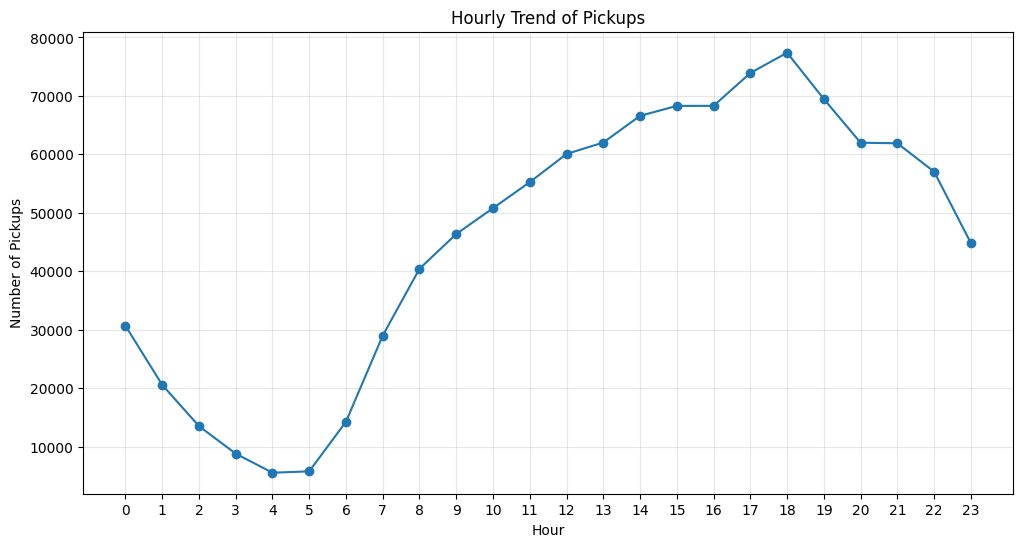

Busiest pickup hour: 18
Least busiest pickup hour: 4


In [33]:
# Find and show the hourly trends in taxi pickups

df['pickup_by_hour'] = df['tpep_pickup_datetime'].dt.hour
pickups_hourly = df['pickup_by_hour'].value_counts().sort_index()
pickups_hourly

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    pickups_hourly.index,
    pickups_hourly.values,
    marker='o'
)

plt.xlabel('Hour')
plt.ylabel('Number of Pickups')
plt.title('Hourly Trend of Pickups')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

# Find busiest and least busiest hour
busy_hour = pickups_hourly.idxmax()
least_busy_hour = pickups_hourly.idxmin()
print("Busiest pickup hour:", busy_hour)
print("Least busiest pickup hour:", least_busy_hour)

# Plot shows that pickups ar emore during evening hours and drops during the night till early monring hours

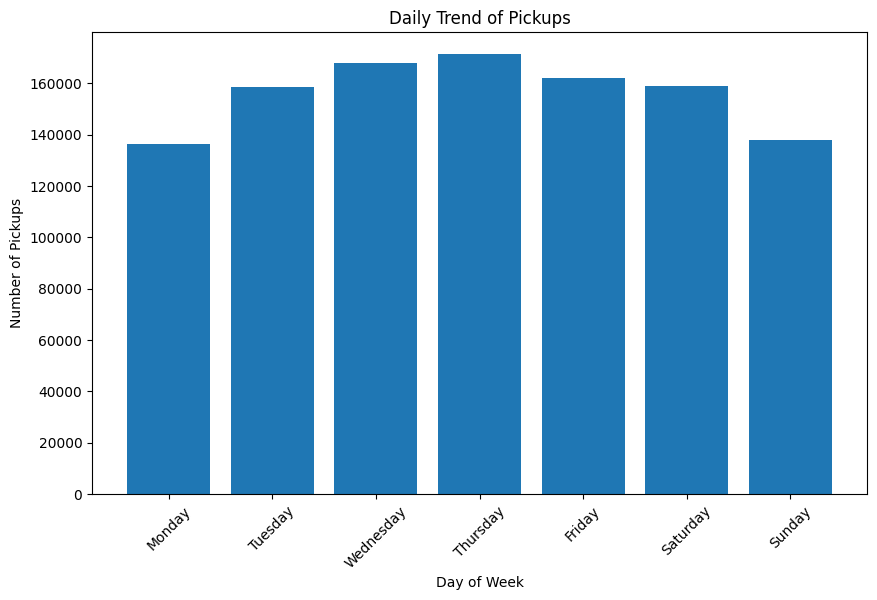

Busiest day: Thursday
Least busy day: Monday


In [34]:
# Find and show the daily trends in taxi pickups (days of the week)

df['pickup_by_day'] = df['tpep_pickup_datetime'].dt.day_name()

#pickups by day
days_list = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

pickups_daily = (
    df['pickup_by_day']
    .value_counts()
    .reindex(days_list)
)

pickups_daily

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    pickups_daily.index,
    pickups_daily.values
)

plt.xlabel('Day of Week')
plt.ylabel('Number of Pickups')
plt.title('Daily Trend of Pickups')
plt.xticks(rotation=45)

plt.show()

busiest_day = pickups_daily.idxmax()
quietest_day = pickups_daily.idxmin()

print("Busiest day:", busiest_day)
print("Least busy day:", quietest_day)

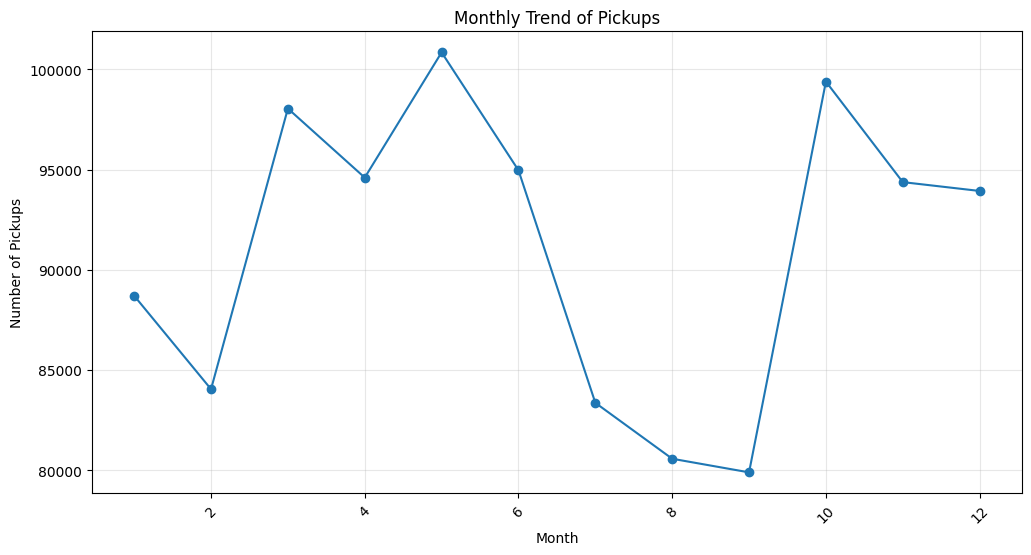

Busiest month: 5
Quietest month: 9


In [35]:
# Show the monthly trends in pickups
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

pickups_monthly = (
    df['pickup_month']
    .value_counts()
    .sort_index()
)

pickups_monthly

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    pickups_monthly.index,
    pickups_monthly.values,
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.title('Monthly Trend of Pickups')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

print("Busiest month:", pickups_monthly.idxmax())
print("Quietest month:", pickups_monthly.idxmin())

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [36]:
# Analyse the above parameters

cols = [
    'fare_amount',
    'tip_amount',
    'total_amount',
    'trip_distance'
]

for col in cols:
    print(f"\n{col}")
    print("Zero values:", (df[col] == 0).sum())
    print("Negative values:", (df[col] < 0).sum())


fare_amount
Zero values: 340
Negative values: 0

tip_amount
Zero values: 239904
Negative values: 0

total_amount
Zero values: 135
Negative values: 0

trip_distance
Zero values: 13042
Negative values: 0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

> Yes. It is beneficial to create a new copy as these values might distort calulcations and outcomes



**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [37]:
# Create a df with non zero entries for the selected parameters.

# I will leave out trip_distance with zero distance as pickup and drop in the same zone, can be for various reasons (Cancellation etc), but still be charged.

df_fin_parameters = df[
    (df['fare_amount'] != 0) &
    (df['tip_amount'] != 0) &
    (df['total_amount'] != 0)
].copy()

df_fin_parameters.info()

<class 'pandas.core.frame.DataFrame'>
Index: 852803 entries, 0 to 1137822
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   vendor_id              852803 non-null  int64         
 1   tpep_pickup_datetime   852803 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  852803 non-null  datetime64[ns]
 3   passenger_count        852803 non-null  int64         
 4   trip_distance          852803 non-null  float64       
 5   rate_code_id           852803 non-null  int64         
 6   store_and_fwd_flag     852803 non-null  object        
 7   pu_location_id         852803 non-null  int64         
 8   do_location_id         852803 non-null  int64         
 9   payment_type           852803 non-null  int64         
 10  fare_amount            852803 non-null  float64       
 11  extra                  852803 non-null  float64       
 12  mta_tax                852803 non-null  float64 

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

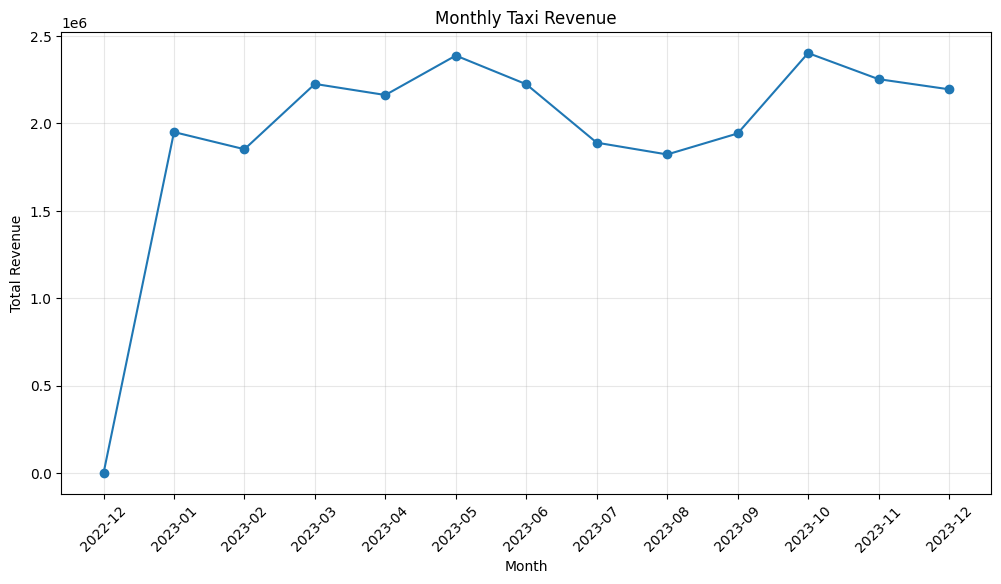

Highest revenue month:
month              2023-10
total_amount    2402219.26
Name: 10, dtype: object

 Lowest revenue month:
month           2022-12
total_amount       13.5
Name: 0, dtype: object


In [38]:
# Group data by month and analyse monthly revenue

df_fin_parameters['month'] = df_fin_parameters['tpep_pickup_datetime'].dt.to_period('M')

monthly_revenue = (
    df_fin_parameters.groupby('month')['total_amount']
      .sum()
      .reset_index()
)

monthly_revenue

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue['month'].astype(str),
    monthly_revenue['total_amount'],
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Monthly Taxi Revenue')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

highest_revenue = monthly_revenue.loc[
    monthly_revenue['total_amount'].idxmax()
]

lowest_revenue = monthly_revenue.loc[
    monthly_revenue['total_amount'].idxmin()
]

print("Highest revenue month:")
print(highest_revenue)

print("\n Lowest revenue month:")
print(lowest_revenue)

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [39]:
# Calculate proportion of each quarter
# Create quarter column
df_fin_parameters['pickup_quarter'] = df_fin_parameters['tpep_pickup_datetime'].dt.to_period('Q')

quarterly_revenue = (
    df_fin_parameters.groupby('pickup_quarter')['total_amount']
      .sum()
      .reset_index(name='revenue')
)

quarterly_revenue['revenue_proportion'] = (
    quarterly_revenue['revenue'] /
    quarterly_revenue['revenue'].sum()
)

quarterly_revenue['revenue_percentage'] = (
    quarterly_revenue['revenue_proportion'] * 100
).round(2)

quarterly_revenue

,pickup_quarter,revenue,revenue_proportion,revenue_percentage
0,2022Q4,13.50,5.334344e-07,0.00
1,2023Q1,6028367.32,2.382029e-01,23.82
2,2023Q2,6774289.71,2.676770e-01,26.77
3,2023Q3,5654665.98,2.234366e-01,22.34
4,2023Q4,6850366.08,2.706830e-01,27.07


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

Correlation between trip distance and fare amount: 0.949


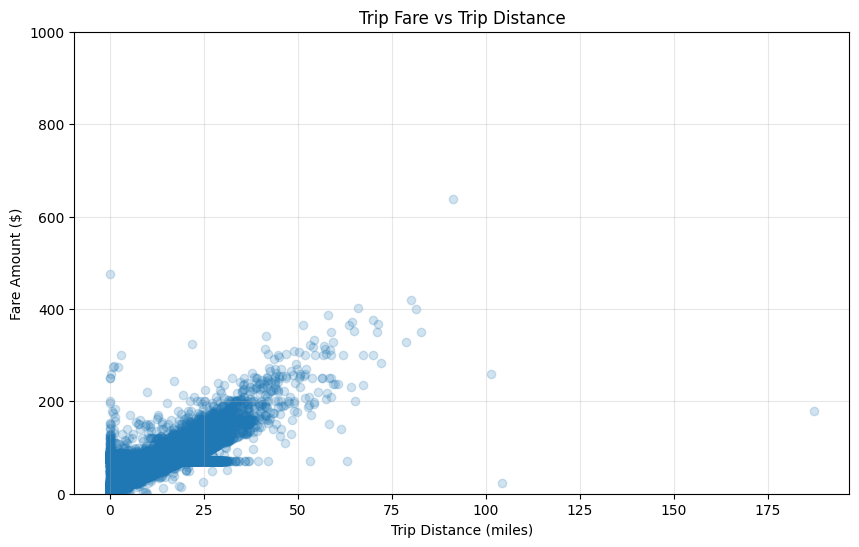

In [40]:
# Show how trip fare is affected by distance

distance_fare = df_fin_parameters[
    (df_fin_parameters['trip_distance'] > 0) &
    (df_fin_parameters['fare_amount'] > 0)
].copy()

correlation = distance_fare['trip_distance'].corr(
    distance_fare['fare_amount']
)

print("Correlation between trip distance and fare amount:",
      round(correlation, 3))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    distance_fare['trip_distance'],
    distance_fare['fare_amount'],
    alpha=0.2
)

plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.title('Trip Fare vs Trip Distance')

plt.ylim(0, 1000)

plt.grid(True, alpha=0.3)
plt.show()


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Correlation between trip duration and fare amount: 0.321


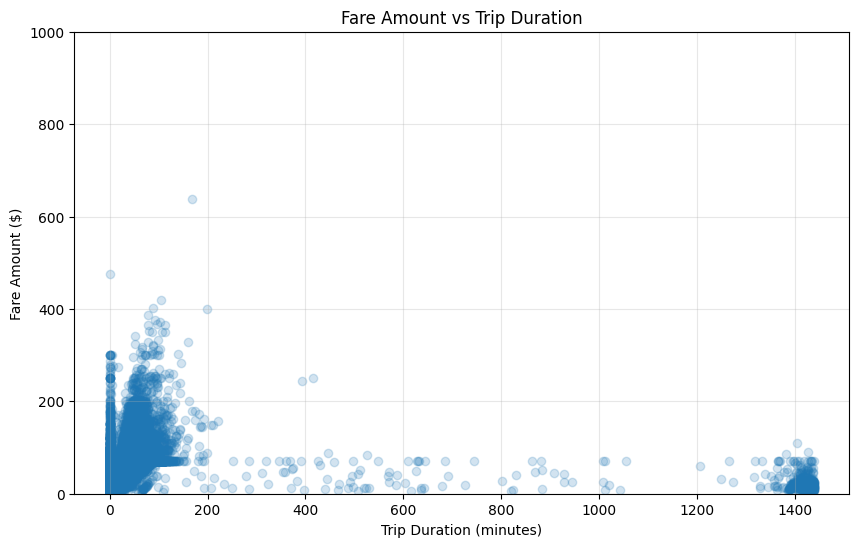

In [41]:
# Show relationship between fare and trip duration
fare_duration = df_fin_parameters[
    (df_fin_parameters['trip_duration'] > 0) &
    (df_fin_parameters['fare_amount'] > 0)
].copy()

correlation = fare_duration['trip_duration'].corr(
    fare_duration['fare_amount']
)

print("Correlation between trip duration and fare amount:",
      round(correlation, 3))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    fare_duration['trip_duration'],
    fare_duration['fare_amount'],
    alpha=0.2
)

plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.title('Fare Amount vs Trip Duration')

plt.ylim(0, 1000)

plt.grid(True, alpha=0.3)
plt.show()


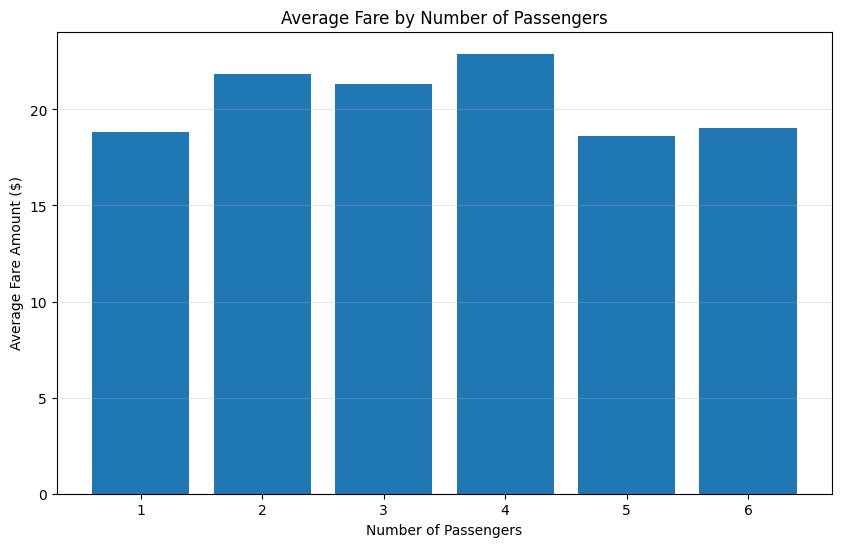

Correlation: 0.041


In [42]:
# Show relationship between fare and number of passengers

fare_passengers = (
    df_fin_parameters.groupby('passenger_count')['fare_amount']
      .agg(['mean', 'count'])
      .reset_index()
)

fare_passengers

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    fare_passengers['passenger_count'],
    fare_passengers['mean']
)

plt.xlabel('Number of Passengers')
plt.ylabel('Average Fare Amount ($)')
plt.title('Average Fare by Number of Passengers')
plt.xticks(fare_passengers['passenger_count'])

plt.grid(axis='y', alpha=0.3)
plt.show()

correlation = df_fin_parameters['passenger_count'].corr(df_fin_parameters['fare_amount'])

print("Correlation:", round(correlation, 3))

Correlation between trip distance and tip amount: 0.8


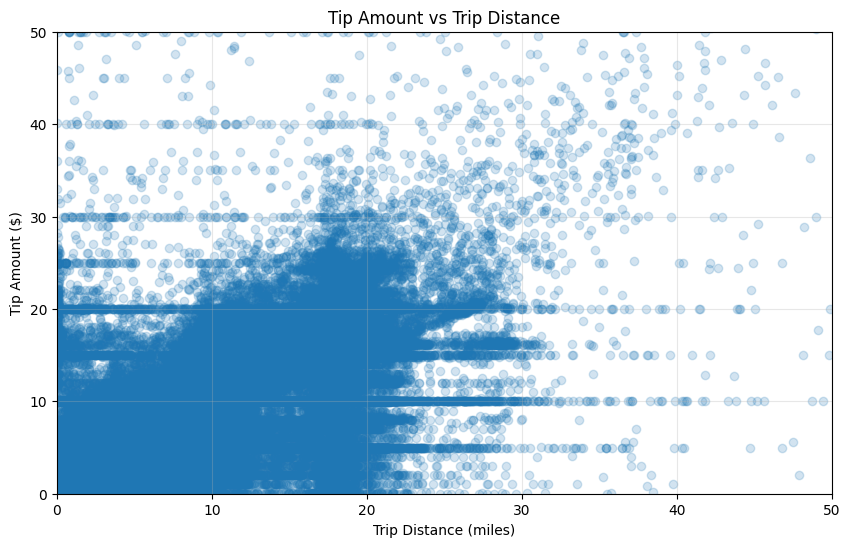

In [43]:
# Show relationship between tip and trip distance

tip_distance = df_fin_parameters[
    (df_fin_parameters['trip_distance'] > 0) &
    (df_fin_parameters['tip_amount'] >= 0)
].copy()

correlation = tip_distance['trip_distance'].corr(
    tip_distance['tip_amount']
)

print("Correlation between trip distance and tip amount:",
      round(correlation, 3))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    tip_distance['trip_distance'],
    tip_distance['tip_amount'],
    alpha=0.2
)

plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.title('Tip Amount vs Trip Distance')

plt.xlim(0, 50)
plt.ylim(0, 50)

plt.grid(True, alpha=0.3)
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

payment_type
1    852728
2        13
3        45
4        17
Name: count, dtype: int64
payment_type
1    99.99
2     0.00
3     0.01
4     0.00
Name: proportion, dtype: float64


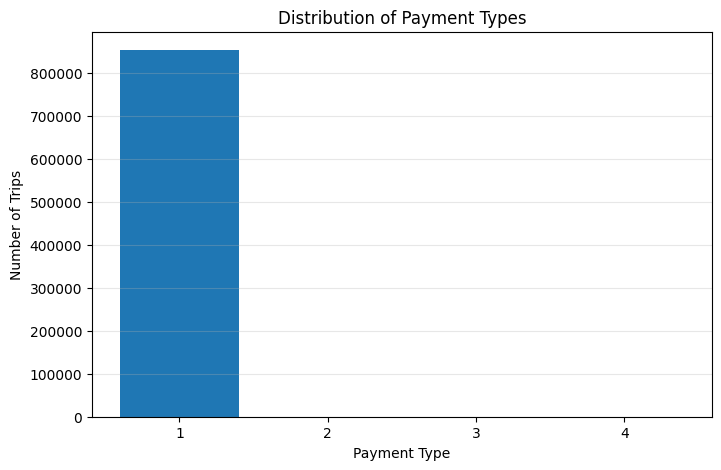

In [44]:
# Analyse the distribution of different payment types (payment_type).

payment_counts = df_fin_parameters['payment_type'].value_counts().sort_index()

print(payment_counts)

payment_percentage = (
    df_fin_parameters['payment_type']
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

print(payment_percentage)

payment_summary = pd.DataFrame({
    'count': payment_counts,
    'percentage': payment_percentage
})

payment_summary

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    payment_summary.index.astype(str),
    payment_summary['count']
)

plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.title('Distribution of Payment Types')

plt.grid(axis='y', alpha=0.3)
plt.show()


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [45]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [46]:
import geopandas as gpd

import os

os.chdir('/content/drive/MyDrive/Taxi Zones')


# Read the shapefile using geopandas
zones = gpd.read_file("taxi_zones.shp")
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

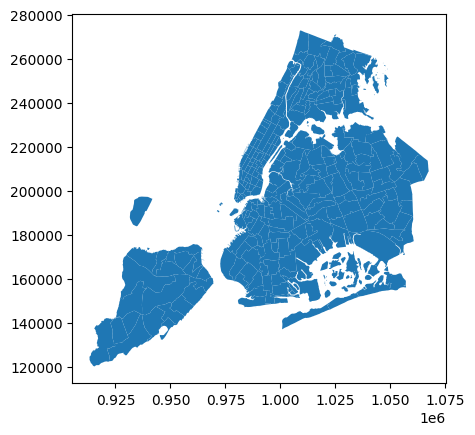

In [47]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [48]:
# Merge zones and trip records using locationID and PULocationID

# Trip data : df_fin_parameters
# Zone Data : zones

zones_with_trips = df_fin_parameters.merge(
    zones,
    left_on = 'pu_location_id',
    right_on = 'LocationID',
    how = 'left'
)

zones_with_trips.head()

,vendor_id,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,rate_code_id,store_and_fwd_flag,pu_location_id,do_location_id,payment_type,...,pickup_month,month,pickup_quarter,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1,0.86,1,N,141,140,1,...,12,2022-12,2022Q4,141.0,0.041514,0.000077,Lenox Hill West,141.0,Manhattan,"POLYGON ((994839.073 216123.698, 994786.74 216..."
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2,1.24,1,N,161,237,1,...,1,2023-01,2023Q1,161.0,0.035804,0.000072,Midtown Center,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."
2,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2,7.10,1,N,246,37,1,...,1,2023-01,2023Q1,246.0,0.069467,0.000281,West Chelsea/Hudson Yards,246.0,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216..."
3,2,2023-01-01 00:58:00,2023-01-01 01:08:31,2,1.59,1,N,79,164,1,...,1,2023-01,2023Q1,79.0,0.042625,0.000108,East Village,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."
4,2,2023-01-01 00:16:06,2023-01-01 00:31:59,1,3.16,1,N,79,256,1,...,1,2023-01,2023Q1,79.0,0.042625,0.000108,East Village,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [49]:
# Group data by location and calculate the number of trips

pickup_trips = (
    df_fin_parameters.groupby('pu_location_id')
      .size()
      .reset_index(name='total_trips')
      .sort_values('total_trips', ascending=False)
)

pickup_trips.head(10)

,pu_location_id,total_trips
195,237,42198
132,161,40817
194,236,38545
107,132,38445
133,162,31786
113,138,31119
116,142,29398
153,186,29109
188,230,26817
141,170,25831


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [50]:
# Merge trip counts back to the zones GeoDataFrame

zones = zones.merge(
    pickup_trips,
    left_on = 'LocationID',
    right_on = 'pu_location_id',
    how = 'left'
)

zones.head()




,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,pu_location_id,total_trips
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,73.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0,1.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",NaN,NaN
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,842.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN,NaN


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

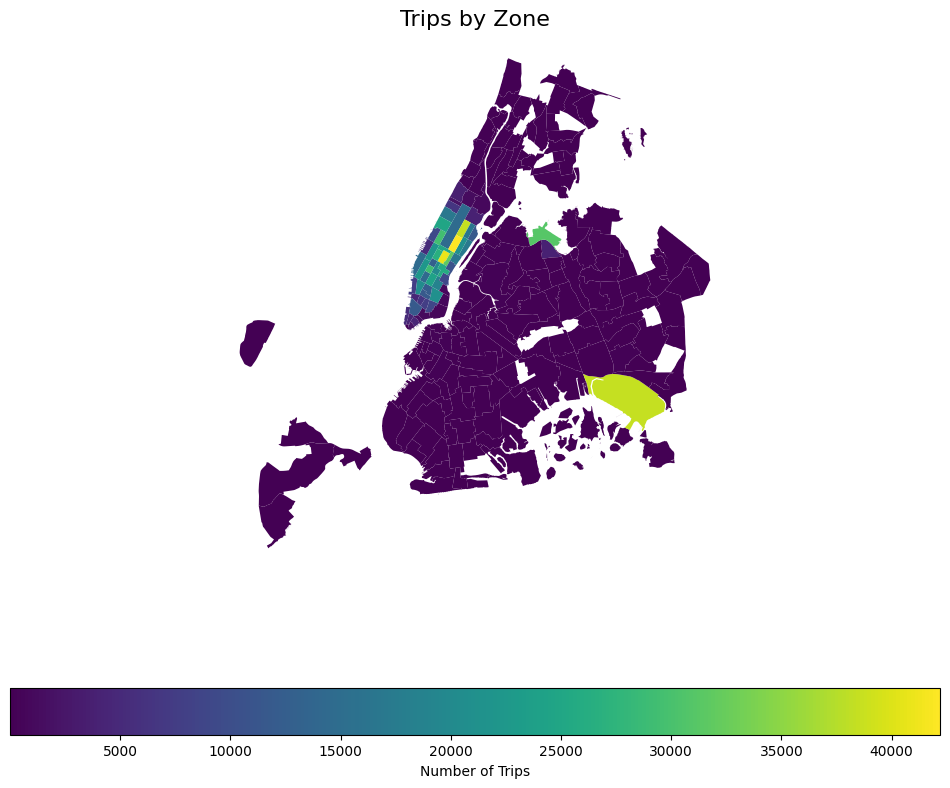

In [51]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot the map and display it
zones.plot(
    column='total_trips',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': 'Number of Trips',
        'orientation': 'horizontal'
    }
)

# Add title
ax.set_title(
    'Trips by Zone',
    fontsize=16
)

# Remove axis
ax.set_axis_off()

# Display plot
plt.show()


In [52]:
# can you try displaying the zones DF sorted by the number of trips?

zones_sorted = zones.sort_values(
    by='total_trips',
    ascending=False
)

zones_sorted[
    ['LocationID', 'zone', 'borough', 'total_trips']
]

zones_sorted.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,pu_location_id,total_trips
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",237.0,42198.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",161.0,40817.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",236.0,38545.0
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",132.0,38445.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",162.0,31786.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [53]:
# Find routes which have the slowest speeds at different times of the day

route_data = df_fin_parameters[
    (df_fin_parameters['trip_distance'] > 0) &
    (df_fin_parameters['trip_duration'] > 0)
].copy()

route_data['pickup_hour'] = route_data['tpep_pickup_datetime'].dt.hour

route_hour = (
    route_data.groupby(
        ['pu_location_id', 'do_location_id', 'pickup_hour']
    )
    .agg(
        avg_trip_duration=('trip_duration', 'mean'),
        avg_distance=('trip_distance', 'mean'),
        trip_count=('trip_duration', 'count')
    )
    .reset_index()
)

route_hour['avg_speed_mph'] = (
    route_hour['avg_distance'] /
    (route_hour['avg_trip_duration'] / 60)
)

slow_routes = (
    route_hour[route_hour['trip_count'] >= 10]
    .sort_values('avg_speed_mph')
)

slow_routes.head(20)

slow_routes = slow_routes.merge(
    zones[['LocationID', 'zone']].rename(
        columns={
            'LocationID': 'pu_location_id',
            'zone': 'pickup_zone'
        }
    ),
    on='pu_location_id',
    how='left'
)

slow_routes = slow_routes.merge(
    zones[['LocationID', 'zone']].rename(
        columns={
            'LocationID': 'do_location_id',
            'zone': 'dropoff_zone'
        }
    ),
    on='do_location_id',
    how='left'
)

slow_routes[
    [
        'pickup_zone',
        'dropoff_zone',
        'pickup_hour',
        'avg_distance',
        'avg_trip_duration',
        'avg_speed_mph',
        'trip_count'
    ]
]

slow_routes = slow_routes.sort_values(
    by='avg_speed_mph',
    ascending=True
)

slow_routes.head(20)

,pu_location_id,do_location_id,pickup_hour,avg_trip_duration,avg_distance,trip_count,avg_speed_mph,pickup_zone,dropoff_zone
0,113,113,13,123.287500,0.514167,12,0.250228,Greenwich Village North,Greenwich Village North
1,113,234,1,123.101389,0.958333,12,0.467095,Greenwich Village North,Union Sq
2,79,79,14,115.102564,0.902308,13,0.470350,East Village,East Village
3,234,113,0,106.478571,0.870000,14,0.490239,Union Sq,Greenwich Village North
4,170,230,23,109.528571,1.033571,14,0.566193,Murray Hill,Times Sq/Theatre District
5,90,100,19,92.961765,0.914706,17,0.590376,Flatiron,Garment District
6,48,230,14,76.427778,0.765238,21,0.600754,Clinton East,Times Sq/Theatre District
7,158,211,14,130.888889,1.414167,12,0.648260,Meatpacking/West Village West,SoHo
8,90,224,17,126.529167,1.369167,12,0.649257,Flatiron,Stuy Town/Peter Cooper Village
9,50,142,21,117.143590,1.320000,13,0.676093,Clinton West,Lincoln Square East


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

Busiest hour: 18
Number of trips: 61819


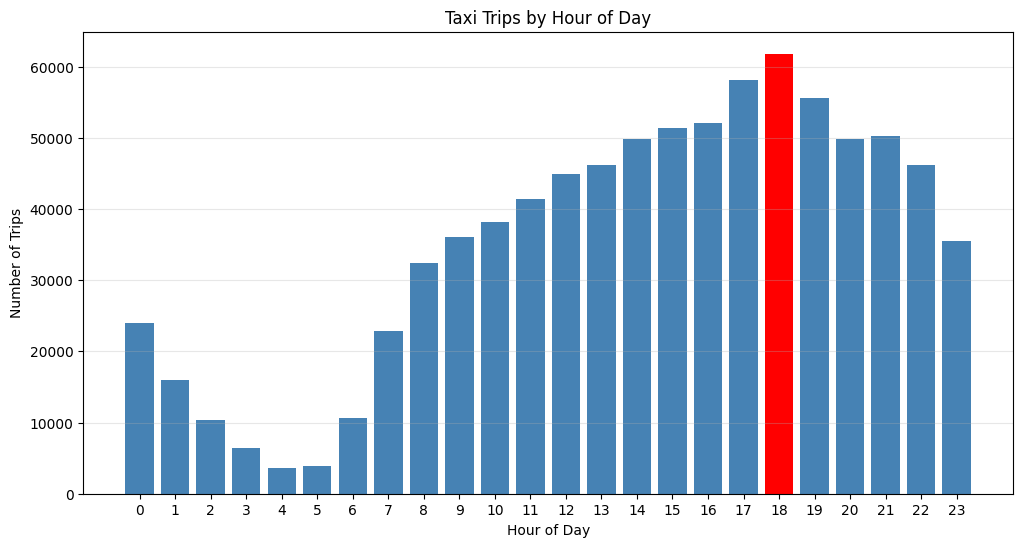

In [54]:
# Visualise the number of trips per hour and find the busiest hour

hourly_trips = (
    route_data.groupby('pickup_hour')
      .size()
      .reset_index(name='trip_count')
)

hourly_trips

hourly_trips = hourly_trips.sort_values('pickup_hour')

busiest_hour = hourly_trips.loc[
    hourly_trips['trip_count'].idxmax()
]

print("Busiest hour:", busiest_hour['pickup_hour'])
print("Number of trips:", busiest_hour['trip_count'])


# Find busiest hour
plt.figure(figsize=(12, 6))

colors = [
    'red' if hour == busiest_hour['pickup_hour'] else 'steelblue'
    for hour in hourly_trips['pickup_hour']
]

plt.bar(
    hourly_trips['pickup_hour'],
    hourly_trips['trip_count'],
    color=colors
)

plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Taxi Trips by Hour of Day')

plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.show()


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [55]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.03

top_5_hours = (
    hourly_trips
    .sort_values('trip_count', ascending=False)
    .head(5)
    .copy()
)

top_5_hours

top_5_hours['actual_trips'] = (
    top_5_hours['trip_count'] / sample_fraction
).round().astype(int)

top_5_hours



,pickup_hour,trip_count,actual_trips
18,18,61819,2060633
17,17,58184,1939467
19,19,55662,1855400
16,16,52080,1736000
15,15,51376,1712533


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

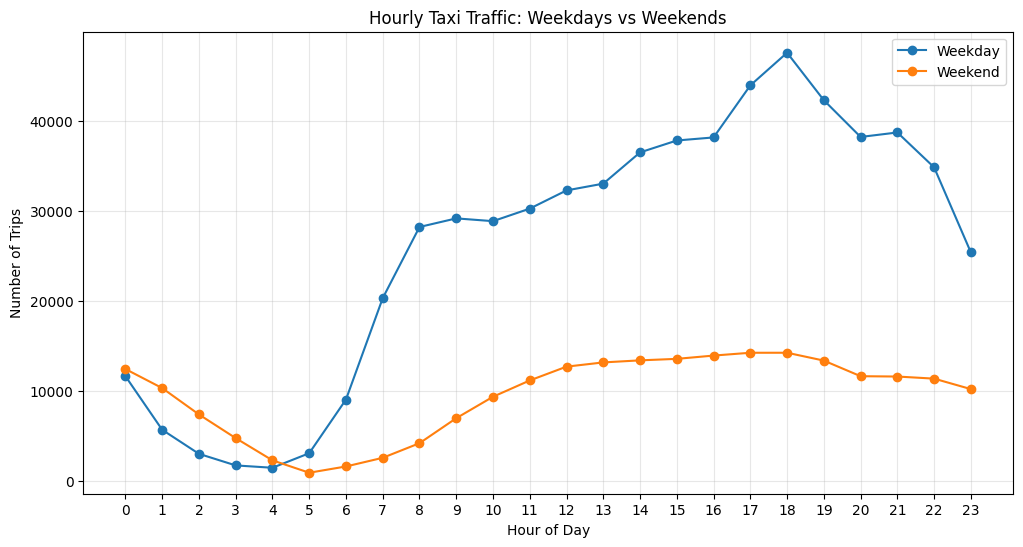

Weekday busiest hour: 18:00 (47,599 trips)
Weekend busiest hour: 18:00 (14,220 trips)


In [56]:
# Compare traffic trends for the week days and weekends

route_data['day_of_week'] = route_data['tpep_pickup_datetime'].dt.day_name()

route_data['is_weekend'] = route_data['tpep_pickup_datetime'].dt.dayofweek >= 5

hourly_pattern = (
    route_data.groupby(['is_weekend', 'pickup_hour'])
      .size()
      .reset_index(name='trip_count')
)

weekday_trips = hourly_pattern[
    hourly_pattern['is_weekend'] == False
]

weekend_trips = hourly_pattern[
    hourly_pattern['is_weekend'] == True
]

comparison = (
    hourly_pattern
    .pivot(
        index='pickup_hour',
        columns='is_weekend',
        values='trip_count'
    )
    .rename(columns={
        False: 'Weekday',
        True: 'Weekend'
    })
)

comparison

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    comparison.index,
    comparison['Weekday'],
    marker='o',
    label='Weekday'
)

plt.plot(
    comparison.index,
    comparison['Weekend'],
    marker='o',
    label='Weekend'
)

plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Hourly Taxi Traffic: Weekdays vs Weekends')
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

weekday_busiest = comparison['Weekday'].idxmax()
weekend_busiest = comparison['Weekend'].idxmax()

print(
    f"Weekday busiest hour: {weekday_busiest:02d}:00 "
    f"({comparison.loc[weekday_busiest, 'Weekday']:,} trips)"
)

print(
    f"Weekend busiest hour: {weekend_busiest:02d}:00 "
    f"({comparison.loc[weekend_busiest, 'Weekend']:,} trips)"
)

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

What can you infer from the above patterns?
1.  Weekdays and weekends have different patterns.
2.  Quiet hours indicate lower demand

Finding busy and quiet hours for each day help us to:

1.   Taxi positioning
2.   Increase or decrease taxi availability





**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [57]:
# Find top 10 pickup and dropoff zones

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy
df_trip = df_fin_parameters.copy()

# Make sure IDs have the same type
df_trip['pu_location_id'] = pd.to_numeric(
    df_trip['pu_location_id'], errors='coerce'
).astype('Int64')

df_trip['do_location_id'] = pd.to_numeric(
    df_trip['do_location_id'], errors='coerce'
).astype('Int64')

zones['LocationID'] = pd.to_numeric(
    zones['LocationID'], errors='coerce'
).astype('Int64')

# Create pickup zone lookup
pickup_lookup = (
    zones[['LocationID', 'zone', 'borough']]
    .drop_duplicates('LocationID')
)

# Create dropoff zone lookup
dropoff_lookup = (
    zones[['LocationID', 'zone', 'borough']]
    .drop_duplicates('LocationID')
)

# Merge pickup information
df_trip = df_trip.merge(
    pickup_lookup.rename(columns={
        'LocationID': 'pu_location_id',
        'zone': 'pickup_zone',
        'borough': 'pickup_borough'
    }),
    on='pu_location_id',
    how='left'
)

# Merge dropoff information
df_trip = df_trip.merge(
    dropoff_lookup.rename(columns={
        'LocationID': 'do_location_id',
        'zone': 'dropoff_zone',
        'borough': 'dropoff_borough'
    }),
    on='do_location_id',
    how='left'
)

print(df_trip.columns.tolist())

# Top 10 pickup zones
top_10_pickup = (
    df_trip.groupby(
        ['pu_location_id', 'pickup_zone', 'pickup_borough'],
        dropna=False
    )
    .size()
    .reset_index(name='pickup_count')
    .sort_values('pickup_count', ascending=False)
    .head(10)
)

print("\n TOP 10 pickup zones \n\n")
display(top_10_pickup)

#Top 10 drop off zones
top_10_dropoff = (
    df_trip.groupby(
        ['do_location_id', 'dropoff_zone', 'dropoff_borough'],
        dropna=False
    )
    .size()
    .reset_index(name='dropoff_count')
    .sort_values('dropoff_count', ascending=False)
    .head(10)
)

print("\n TOP 10 dropoff zones \n\n")
display(top_10_dropoff)

df_trip['pickup_hour'] = df_trip['tpep_pickup_datetime'].dt.hour
df_trip['dropoff_hour'] = df_trip['tpep_dropoff_datetime'].dt.hour

top_pickup_ids = top_10_pickup['pu_location_id'].tolist()

hourly_pickups = (
    df_trip[df_trip['pu_location_id'].isin(top_pickup_ids)]
    .groupby(['pickup_zone', 'pickup_hour'])
    .size()
    .reset_index(name='pickup_count')
)

display(hourly_pickups.head(10))

top_dropoff_ids = top_10_dropoff['do_location_id'].tolist()

hourly_dropoffs = (
    df_trip[df_trip['do_location_id'].isin(top_dropoff_ids)]
    .groupby(['dropoff_zone', 'dropoff_hour'])
    .size()
    .reset_index(name='dropoff_count')
)

display(hourly_dropoffs.head(10))

['vendor_id', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'rate_code_id', 'store_and_fwd_flag', 'pu_location_id', 'do_location_id', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'trip_duration', 'pickup_by_hour', 'pickup_by_day', 'pickup_month', 'month', 'pickup_quarter', 'pickup_zone', 'pickup_borough', 'dropoff_zone', 'dropoff_borough']

 TOP 10 pickup zones 




,pu_location_id,pickup_zone,pickup_borough,pickup_count
195,237,Upper East Side South,Manhattan,42198
132,161,Midtown Center,Manhattan,40817
194,236,Upper East Side North,Manhattan,38545
107,132,JFK Airport,Queens,38445
133,162,Midtown East,Manhattan,31786
113,138,LaGuardia Airport,Queens,31119
116,142,Lincoln Square East,Manhattan,29398
153,186,Penn Station/Madison Sq West,Manhattan,29109
188,230,Times Sq/Theatre District,Manhattan,26817
141,170,Murray Hill,Manhattan,25831



 TOP 10 dropoff zones 




,do_location_id,dropoff_zone,dropoff_borough,dropoff_count
227,236,Upper East Side North,Manhattan,40901
228,237,Upper East Side South,Manhattan,37750
153,161,Midtown Center,Manhattan,33089
162,170,Murray Hill,Manhattan,26073
230,239,Upper West Side South,Manhattan,25634
154,162,Midtown East,Manhattan,25072
134,142,Lincoln Square East,Manhattan,24967
133,141,Lenox Hill West,Manhattan,23900
221,230,Times Sq/Theatre District,Manhattan,23712
65,68,East Chelsea,Manhattan,21850


,pickup_zone,pickup_hour,pickup_count
0,JFK Airport,0,1624
1,JFK Airport,1,694
2,JFK Airport,2,218
3,JFK Airport,3,142
4,JFK Airport,4,103
5,JFK Airport,5,439
6,JFK Airport,6,1150
7,JFK Airport,7,1217
8,JFK Airport,8,1027
9,JFK Airport,9,981


,dropoff_zone,dropoff_hour,dropoff_count
0,East Chelsea,0,695
1,East Chelsea,1,488
2,East Chelsea,2,334
3,East Chelsea,3,208
4,East Chelsea,4,115
5,East Chelsea,5,117
6,East Chelsea,6,251
7,East Chelsea,7,513
8,East Chelsea,8,825
9,East Chelsea,9,996


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [58]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Pickup counts by zone
pickup_counts = (
    df_trip.groupby('pu_location_id')
      .size()
      .reset_index(name='pickup_count')
)

# Dropoff counts by zone
dropoff_counts = (
    df_trip.groupby('do_location_id')
      .size()
      .reset_index(name='dropoff_count')
)

# Combine pickup and dropoff counts
zone_ratio = pd.merge(
    pickup_counts,
    dropoff_counts,
    left_on='pu_location_id',
    right_on='do_location_id',
    how='outer'
)

# Create one LocationID column
zone_ratio['LocationID'] = (
    zone_ratio['pu_location_id']
    .combine_first(zone_ratio['do_location_id'])
)

# Fill missing counts with 0
zone_ratio['pickup_count'] = zone_ratio['pickup_count'].fillna(0)
zone_ratio['dropoff_count'] = zone_ratio['dropoff_count'].fillna(0)

# Calculate ratio
zone_ratio['pickup_dropoff_ratio'] = (
    zone_ratio['pickup_count'] /
    zone_ratio['dropoff_count'].replace(0, np.nan)
)

# Add zone information
zone_ratio = zone_ratio.merge(
    zones[['LocationID', 'zone', 'borough']].drop_duplicates('LocationID'),
    on='LocationID',
    how='left'
)

# Select useful columns
zone_ratio = zone_ratio[
    [
        'LocationID',
        'zone',
        'borough',
        'pickup_count',
        'dropoff_count',
        'pickup_dropoff_ratio'
    ]
]

import numpy as np

top_10_ratio = (
    zone_ratio
    .dropna(subset=['pickup_dropoff_ratio'])
    .sort_values('pickup_dropoff_ratio', ascending=False)
    .head(10)
)

bottom_10_ratio = (
    zone_ratio
    .dropna(subset=['pickup_dropoff_ratio'])
    .sort_values('pickup_dropoff_ratio', ascending=True)
    .head(10)
)

print("TOP 10 PICKUP RATIOS")
display(
    top_10_ratio.style.format({
        'pickup_count': '{:,.0f}',
        'dropoff_count': '{:,.0f}',
        'pickup_dropoff_ratio': '{:.2f}'
    })
)

print("BOTTOM 10 DROPOFF RATIOS")
display(
    bottom_10_ratio.style.format({
        'pickup_count': '{:,.0f}',
        'dropoff_count': '{:,.0f}',
        'pickup_dropoff_ratio': '{:.2f}'
    })
)

TOP 10 PICKUP RATIOS


,LocationID,zone,borough,pickup_count,dropoff_count,pickup_dropoff_ratio
68,70,East Elmhurst,Queens,"3,830",277,13.83
125,132,JFK Airport,Queens,"38,445","8,338",4.61
131,138,LaGuardia Airport,Queens,"31,119","10,799",2.88
179,186,Penn Station/Madison Sq West,Manhattan,"29,109","17,833",1.63
42,43,Central Park,Manhattan,"14,611","10,399",1.41
107,114,Greenwich Village South,Manhattan,"11,830","8,576",1.38
207,215,South Jamaica,Queens,70,51,1.37
241,249,West Village,Manhattan,"20,423","15,276",1.34
199,207,Saint Michaels Cemetery/Woodside,Queens,4,3,1.33
155,162,Midtown East,Manhattan,"31,786","25,072",1.27


BOTTOM 10 DROPOFF RATIOS


,LocationID,zone,borough,pickup_count,dropoff_count,pickup_dropoff_ratio
56,58,Country Club,Bronx,0,9,0.00
196,204,Rossville/Woodrow,Staten Island,0,1,0.00
213,221,Stapleton,Staten Island,0,7,0.00
206,214,South Beach/Dongan Hills,Staten Island,0,11,0.00
202,210,Sheepshead Bay,Brooklyn,0,71,0.00
198,206,Saint George/New Brighton,Staten Island,0,13,0.00
200,208,Schuylerville/Edgewater Park,Bronx,0,68,0.00
176,183,Pelham Bay,Bronx,0,19,0.00
94,96,Forest Park/Highland Park,Queens,0,6,0.00
165,172,New Dorp/Midland Beach,Staten Island,0,5,0.00


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [59]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Create separate hours for pickup and dropoff
df_pick_drop = df_fin_parameters.copy()

df_pick_drop['pickup_hour'] = df_pick_drop['tpep_pickup_datetime'].dt.hour
df_pick_drop['dropoff_hour'] = df_pick_drop['tpep_dropoff_datetime'].dt.hour

# Night = 11 PM through 5 AM
# This includes: 23, 0, 1, 2, 3, 4, 5
night_pickups = df_pick_drop[
    df_pick_drop['pickup_hour'].isin([23, 0, 1, 2, 3, 4, 5])
].copy()

night_dropoffs = df_pick_drop[
    df_pick_drop['dropoff_hour'].isin([23, 0, 1, 2, 3, 4, 5])
].copy()

# Top 1- night pickups
top_10_night_pickups = (
    night_pickups
    .groupby('pu_location_id')
    .size()
    .reset_index(name='night_pickup_count')
    .sort_values('night_pickup_count', ascending=False)
    .head(10)
)

# Add zone names
top_10_night_pickups = top_10_night_pickups.merge(
    zones[['LocationID', 'zone', 'borough']].drop_duplicates('LocationID'),
    left_on='pu_location_id',
    right_on='LocationID',
    how='left'
)

top_10_night_pickups = top_10_night_pickups[
    ['pu_location_id', 'zone', 'borough', 'night_pickup_count']
]

print("\n TOP 10 night pickups \n\n")
display(top_10_night_pickups)

top_10_night_dropoffs = (
    night_dropoffs
    .groupby('do_location_id')
    .size()
    .reset_index(name='night_dropoff_count')
    .sort_values('night_dropoff_count', ascending=False)
    .head(10)
)

# Add zone names
top_10_night_dropoffs = top_10_night_dropoffs.merge(
    zones[['LocationID', 'zone', 'borough']].drop_duplicates('LocationID'),
    left_on='do_location_id',
    right_on='LocationID',
    how='left'
)

top_10_night_dropoffs = top_10_night_dropoffs[
    ['do_location_id', 'zone', 'borough', 'night_dropoff_count']
]

print("\n TOP 10 night dropoffs \n\n")
display(top_10_night_dropoffs)



 TOP 10 night pickups 




,pu_location_id,zone,borough,night_pickup_count
0,79,East Village,Manhattan,7745
1,249,West Village,Manhattan,6329
2,132,JFK Airport,Queens,5775
3,148,Lower East Side,Manhattan,4872
4,48,Clinton East,Manhattan,4853
5,114,Greenwich Village South,Manhattan,4311
6,230,Times Sq/Theatre District,Manhattan,3574
7,186,Penn Station/Madison Sq West,Manhattan,3167
8,164,Midtown South,Manhattan,2897
9,138,LaGuardia Airport,Queens,2838



 TOP 10 night dropoffs 




,do_location_id,zone,borough,night_dropoff_count
0,79,East Village,Manhattan,4344
1,48,Clinton East,Manhattan,3382
2,170,Murray Hill,Manhattan,3253
3,107,Gramercy,Manhattan,3166
4,141,Lenox Hill West,Manhattan,2967
5,68,East Chelsea,Manhattan,2921
6,263,Yorkville West,Manhattan,2827
7,249,West Village,Manhattan,2722
8,236,Upper East Side North,Manhattan,2580
9,239,Upper West Side South,Manhattan,2487


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [60]:
# Filter for night hours (11 PM to 5 AM)

df_rev = df_fin_parameters.copy()

df_rev['pickup_hour'] = df_rev['tpep_pickup_datetime'].dt.hour

night_hours = [23, 0, 1, 2, 3, 4, 5]

df_rev['time_period'] = np.where(
    df_rev['pickup_hour'].isin(night_hours),
    'Night',
    'Day'
)

#Calculate revenue for each period
revenue_by_period = (
    df_rev.groupby('time_period')['total_amount']
      .sum()
      .reset_index(name='revenue')
)

revenue_by_period

# Reveneue share

total_revenue = revenue_by_period['revenue'].sum()

revenue_by_period['revenue_share'] = (
    revenue_by_period['revenue'] / total_revenue * 100
)

display(
    revenue_by_period.style.format({
        'revenue': '${:,.2f}',
        'revenue_share': '{:.2f}%'
    })
)


,time_period,revenue,revenue_share
0,Day,"$22,268,554.12",87.99%
1,Night,"$3,039,148.47",12.01%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [61]:
# Analyse the fare per mile per passenger for different passenger counts

import numpy as np
import pandas as pd

df_pr = df_fin_parameters.copy()

# Remove invalid trips
df_analysis = df_pr[
    (df_pr['trip_distance'] > 0) &
    (df_pr['passenger_count'] > 0) &
    (df_pr['fare_amount'] >= 0)
].copy()

# Fare per mile for each trip
df_analysis['fare_per_mile'] = (
    df_analysis['fare_amount'] / df_analysis['trip_distance']
)

# Avg fare per mile by passenger count
fare_by_passengers = (
    df_analysis
    .groupby('passenger_count')
    .agg(
        avg_fare_per_mile=('fare_per_mile', 'mean'),
        trip_count=('fare_per_mile', 'size')
    )
    .reset_index()
)

fare_by_passengers['fare_per_mile_per_passenger'] = (
    fare_by_passengers['avg_fare_per_mile'] /
    fare_by_passengers['passenger_count']
)

fare_by_passengers = fare_by_passengers.sort_values('passenger_count')

display(
    fare_by_passengers.style.format({
        'avg_fare_per_mile': '${:.2f}',
        'fare_per_mile_per_passenger': '${:.2f}',
        'trip_count': '{:,.0f}'
    })
)


,passenger_count,avg_fare_per_mile,trip_count,fare_per_mile_per_passenger
0,1,$9.28,"658,046",$9.28
1,2,$10.41,"125,626",$5.21
2,3,$10.52,"30,243",$3.51
3,4,$13.95,"15,155",$3.49
4,5,$7.83,"11,216",$1.57
5,6,$7.70,"7,528",$1.28


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

,pickup_hour,avg_fare_per_mile,trip_count
0,0,$7.97,"24,022"
1,1,$8.82,"15,960"
2,2,$8.15,"10,329"
3,3,$7.42,"6,407"
4,4,$12.12,"3,674"
5,5,$9.86,"3,915"
6,6,$9.55,"10,587"
7,7,$8.79,"22,829"
8,8,$9.41,"32,370"
9,9,$9.25,"36,109"


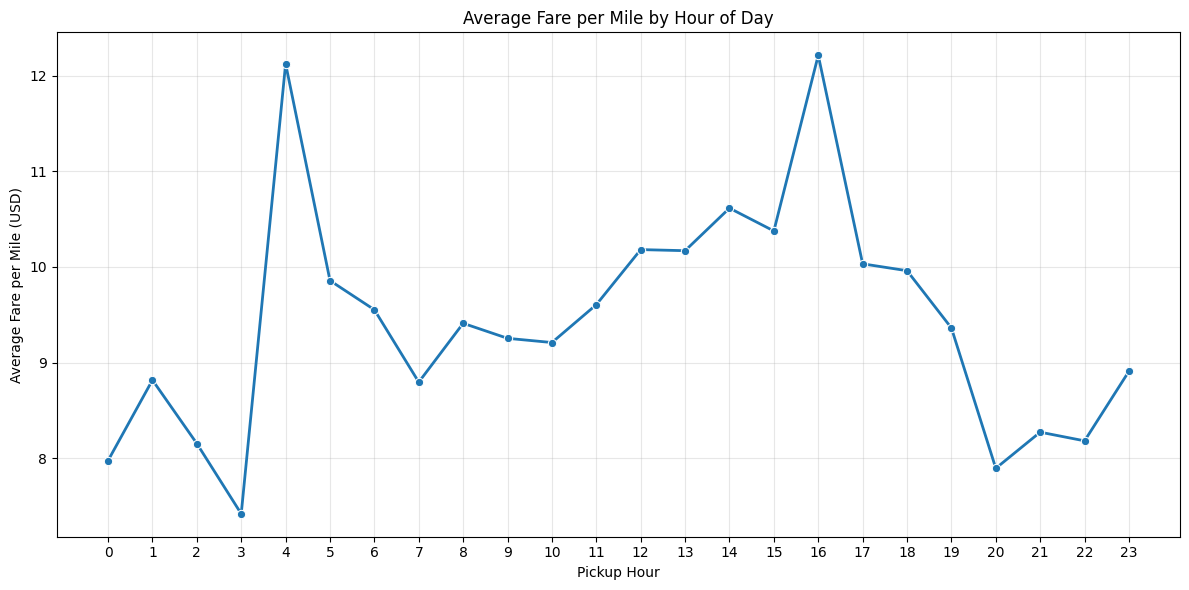

,day_of_week,avg_fare_per_mile,trip_count
0,Monday,$9.01,"104,556"
1,Tuesday,$9.42,"124,182"
2,Wednesday,$9.35,"132,575"
3,Thursday,$9.75,"135,011"
4,Friday,$9.27,"124,780"
5,Saturday,$9.31,"121,867"
6,Sunday,$10.78,"104,843"


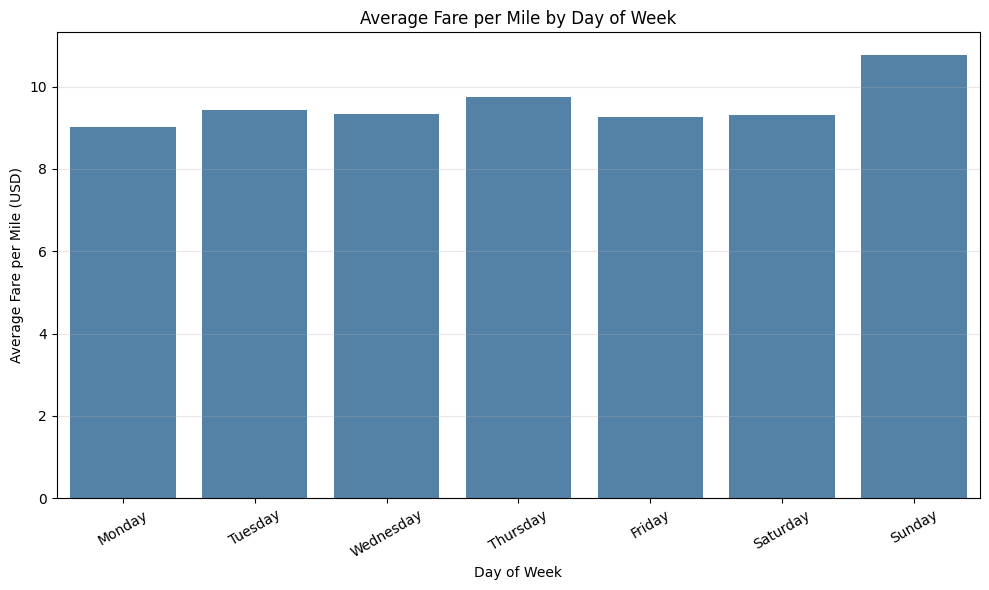

In [62]:
# Compare the average fare per mile for different days and for different times of the day
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_pr = df_fin_parameters.copy()

# Remove invalid trips
df_analysis = df_pr[
    (df_pr['trip_distance'] > 0) &
    (df_pr['fare_amount'] >= 0)
].copy()

# Fare per mile for each trip
df_analysis['fare_per_mile'] = (
    df_analysis['fare_amount'] /
    df_analysis['trip_distance']
)

# Extract hour and day
df_analysis['pickup_hour'] = (
    df_analysis['tpep_pickup_datetime'].dt.hour
)

df_analysis['day_of_week'] = (
    df_analysis['tpep_pickup_datetime'].dt.day_name()
)

# Avg fare per mile by hour
hourly_fare = (
    df_analysis
    .groupby('pickup_hour')
    .agg(
        avg_fare_per_mile=('fare_per_mile', 'mean'),
        trip_count=('fare_per_mile', 'size')
    )
    .reset_index()
    .sort_values('pickup_hour')
)

display(
    hourly_fare.style.format({
        'avg_fare_per_mile': '${:.2f}',
        'trip_count': '{:,.0f}'
    })
)

# Hourly fare per mile
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_fare,
    x='pickup_hour',
    y='avg_fare_per_mile',
    marker='o',
    linewidth=2
)

plt.title('Average Fare per Mile by Hour of Day')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Fare per Mile (USD)')
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#Avg fare per mile by week day

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

daily_fare = (
    df_analysis
    .groupby('day_of_week')
    .agg(
        avg_fare_per_mile=('fare_per_mile', 'mean'),
        trip_count=('fare_per_mile', 'size')
    )
    .reindex(day_order)
    .reset_index()
)

display(
    daily_fare.style.format({
        'avg_fare_per_mile': '${:.2f}',
        'trip_count': '{:,.0f}'
    })
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=daily_fare,
    x='day_of_week',
    y='avg_fare_per_mile',
    color='steelblue'
)

plt.title('Average Fare per Mile by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Fare per Mile (USD)')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

,vendor_id,avg_fare_per_mile,trip_count
1,2,$10.09,"631,355"
0,1,$7.92,"216,459"


,vendor_id,pickup_hour,avg_fare_per_mile,trip_count
0,1,0,$6.85,"5,396"
1,1,1,$6.74,"3,563"
2,1,2,$7.01,"2,414"
3,1,3,$6.36,"1,423"
4,1,4,$7.66,842
5,1,5,$7.96,998
6,1,6,$6.30,"2,950"
7,1,7,$7.01,"6,321"
8,1,8,$7.85,"8,958"
9,1,9,$8.15,"9,935"


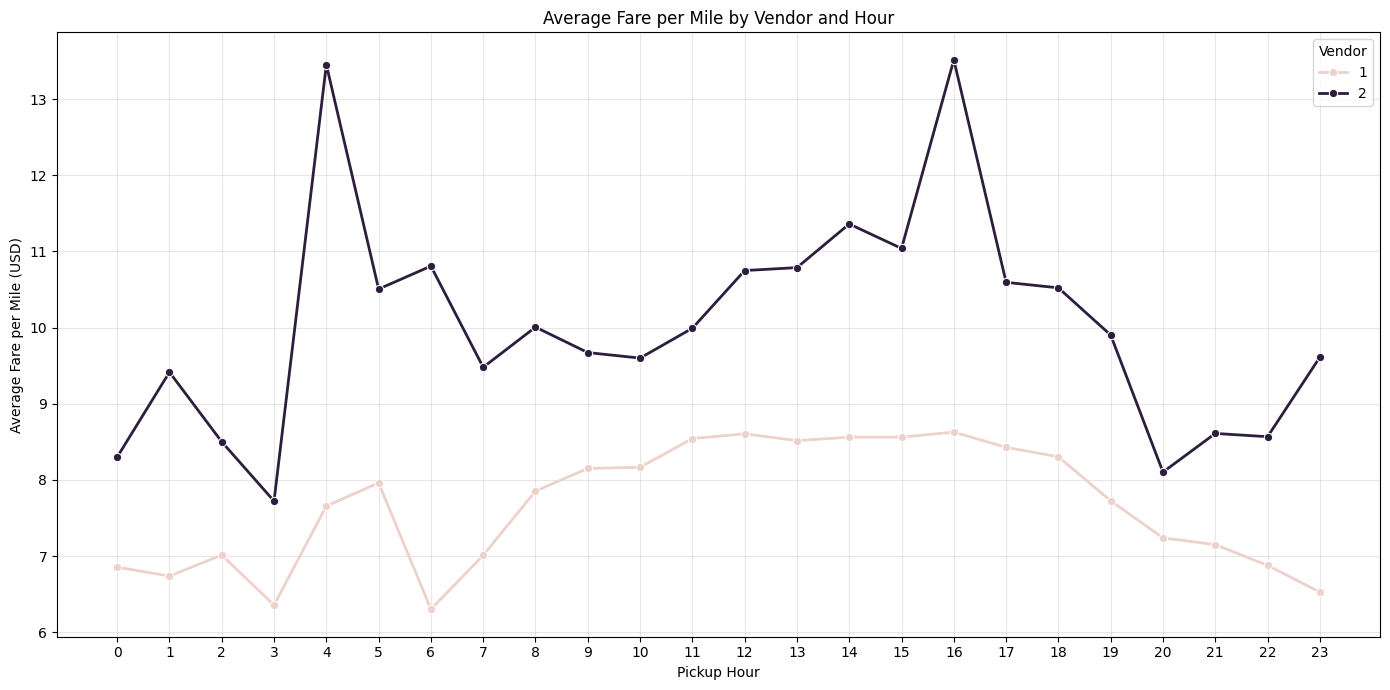

In [63]:
# Compare fare per mile for different vendors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_prc = df_fin_parameters.copy()

# Keep valid trips
df_analysis = df_prc[
    (df_prc['trip_distance'] > 0) &
    (df_prc['fare_amount'] >= 0)
].copy()

# Fare per mile
df_analysis['fare_per_mile'] = (
    df_analysis['fare_amount'] /
    df_analysis['trip_distance']
)

# Pickup hour
df_analysis['pickup_hour'] = (
    df_analysis['tpep_pickup_datetime'].dt.hour
)

# Avg fare per mile for each vendor
vendor_fare = (
    df_analysis
    .groupby('vendor_id')
    .agg(
        avg_fare_per_mile=('fare_per_mile', 'mean'),
        trip_count=('fare_per_mile', 'size')
    )
    .reset_index()
    .sort_values('avg_fare_per_mile', ascending=False)
)

display(
    vendor_fare.style.format({
        'avg_fare_per_mile': '${:.2f}',
        'trip_count': '{:,.0f}'
    })
)

# # Avg fare per mile for each vendor per hour
vendor_hourly_fare = (
    df_analysis
    .groupby(['vendor_id', 'pickup_hour'])
    .agg(
        avg_fare_per_mile=('fare_per_mile', 'mean'),
        trip_count=('fare_per_mile', 'size')
    )
    .reset_index()
)

display(
    vendor_hourly_fare.head(20).style.format({
        'avg_fare_per_mile': '${:.2f}',
        'trip_count': '{:,.0f}'
    })
)

#Comapre

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=vendor_hourly_fare,
    x='pickup_hour',
    y='avg_fare_per_mile',
    hue='vendor_id',
    marker='o',
    linewidth=2
)

plt.title('Average Fare per Mile by Vendor and Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Fare per Mile (USD)')
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.legend(title='Vendor')

plt.tight_layout()
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


,distance_tier,vendor_id,avg_fare_per_mile,trip_count,avg_trip_distance,avg_fare
0,Up to 2 miles,1,$9.50,"126,326",1.17,$10.06
1,Up to 2 miles,2,$13.74,"342,192",1.18,$10.37
2,2 to 5 miles,1,$6.36,"58,725",3.03,$18.92
3,2 to 5 miles,2,$6.54,"180,713",2.99,$19.21
4,More than 5 miles,1,$4.47,"31,408",11.35,$48.69
5,More than 5 miles,2,$4.51,"108,450",11.70,$50.40


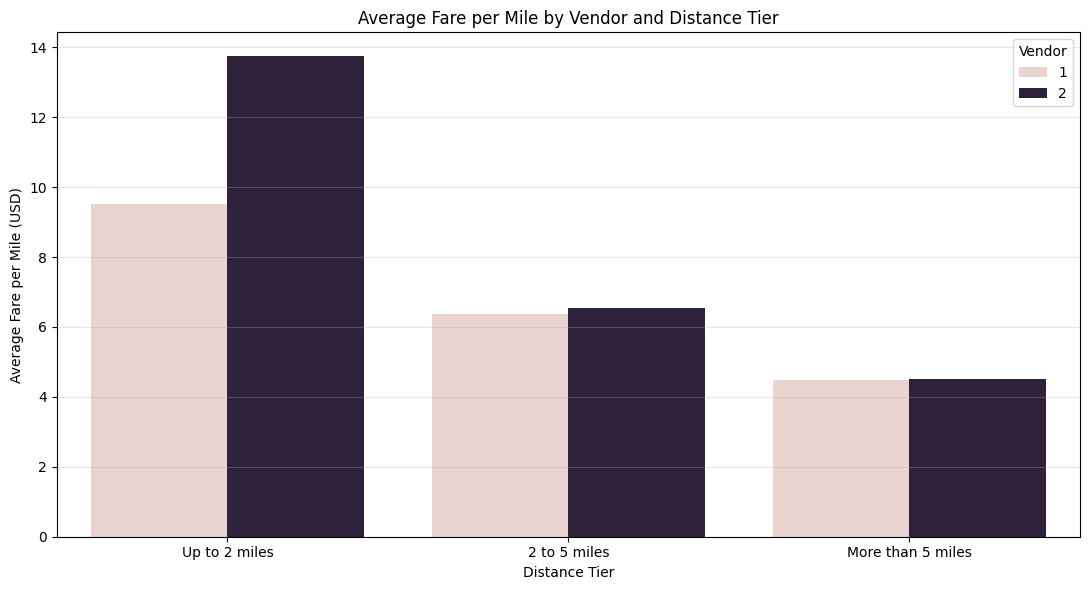

In [64]:
# Defining distance tiers

# Distance tiers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_tier = df_fin_parameters.copy()

# Keep valid trips
df_analysis = df_tier[
    (df_tier['trip_distance'] > 0) &
    (df_tier['fare_amount'] >= 0)
].copy()

# Calculate fare per mile
df_analysis['fare_per_mile'] = (
    df_analysis['fare_amount'] /
    df_analysis['trip_distance']
)

# Create distance tiers
df_analysis['distance_tier'] = pd.cut(
    df_analysis['trip_distance'],
    bins=[0, 2, 5, np.inf],
    labels=[
        'Up to 2 miles',
        '2 to 5 miles',
        'More than 5 miles'
    ],
    right=True
)

# Comapre vendors
vendor_tier_fare = (
    df_analysis
    .groupby(
        ['distance_tier', 'vendor_id'],
        observed=True
    )
    .agg(
        avg_fare_per_mile=('fare_per_mile', 'mean'),
        trip_count=('fare_per_mile', 'size'),
        avg_trip_distance=('trip_distance', 'mean'),
        avg_fare=('fare_amount', 'mean')
    )
    .reset_index()
)

display(
    vendor_tier_fare.style.format({
        'avg_fare_per_mile': '${:.2f}',
        'avg_trip_distance': '{:.2f}',
        'avg_fare': '${:.2f}',
        'trip_count': '{:,.0f}'
    })
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=vendor_tier_fare,
    x='distance_tier',
    y='avg_fare_per_mile',
    hue='vendor_id'
)

plt.title('Average Fare per Mile by Vendor and Distance Tier')
plt.xlabel('Distance Tier')
plt.ylabel('Average Fare per Mile (USD)')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Vendor')

plt.tight_layout()
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

,distance_tier,avg_tip_percentage,median_tip_percentage,trip_count
0,0–2 miles,28.86%,28.72%,"468,518"
1,2–5 miles,23.17%,24.57%,"239,438"
2,5–10 miles,27.57%,23.17%,"70,469"
3,10+ miles,21.44%,23.01%,"69,389"


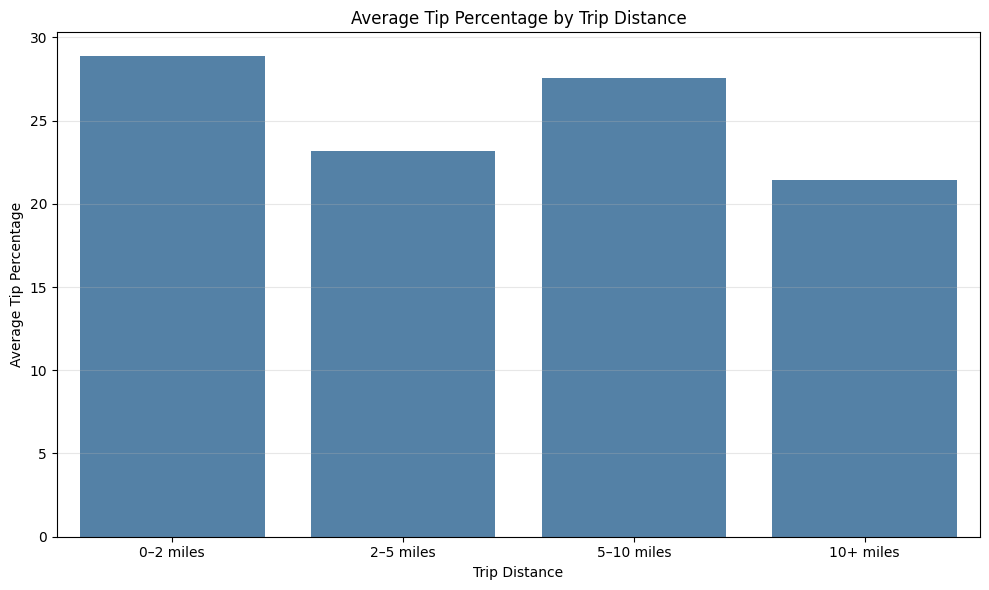

,passenger_count,avg_tip_percentage,median_tip_percentage,trip_count
0,1,26.74%,26.25%,"658,046"
1,2,25.81%,25.93%,"125,626"
2,3,25.88%,25.93%,"30,243"
3,4,25.83%,25.93%,"15,155"
4,5,26.09%,26.25%,"11,216"
5,6,25.98%,26.13%,"7,528"


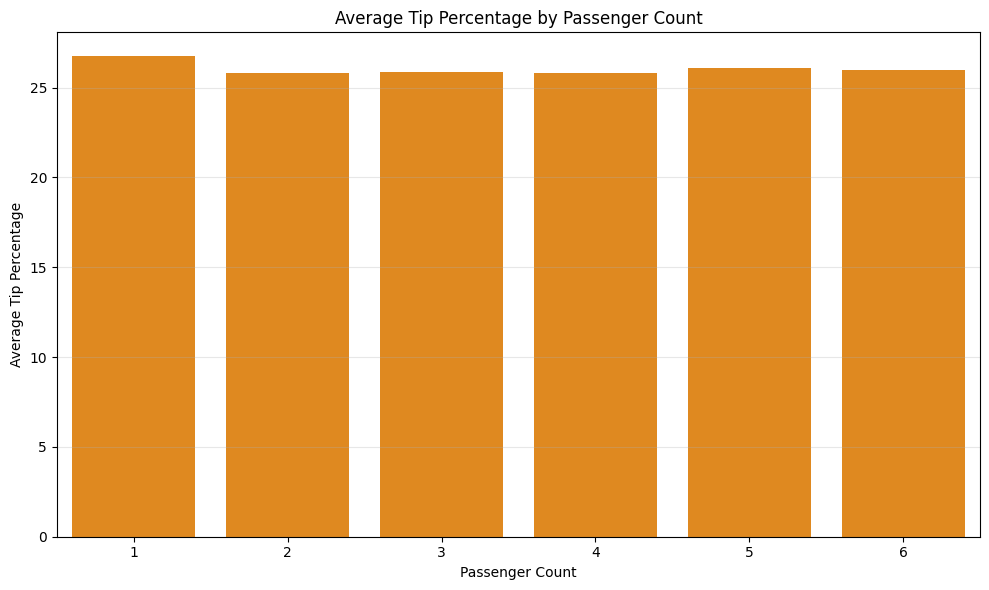

,pickup_hour,avg_tip_percentage,median_tip_percentage,trip_count
0,0,25.96%,26.13%,"24,022"
1,1,26.24%,26.41%,"15,960"
2,2,26.63%,26.71%,"10,329"
3,3,26.89%,26.71%,"6,407"
4,4,26.88%,26.32%,"3,674"
5,5,25.97%,26.13%,"3,915"
6,6,25.42%,25.32%,"10,587"
7,7,24.98%,25.63%,"22,829"
8,8,24.99%,25.37%,"32,370"
9,9,25.28%,25.63%,"36,109"


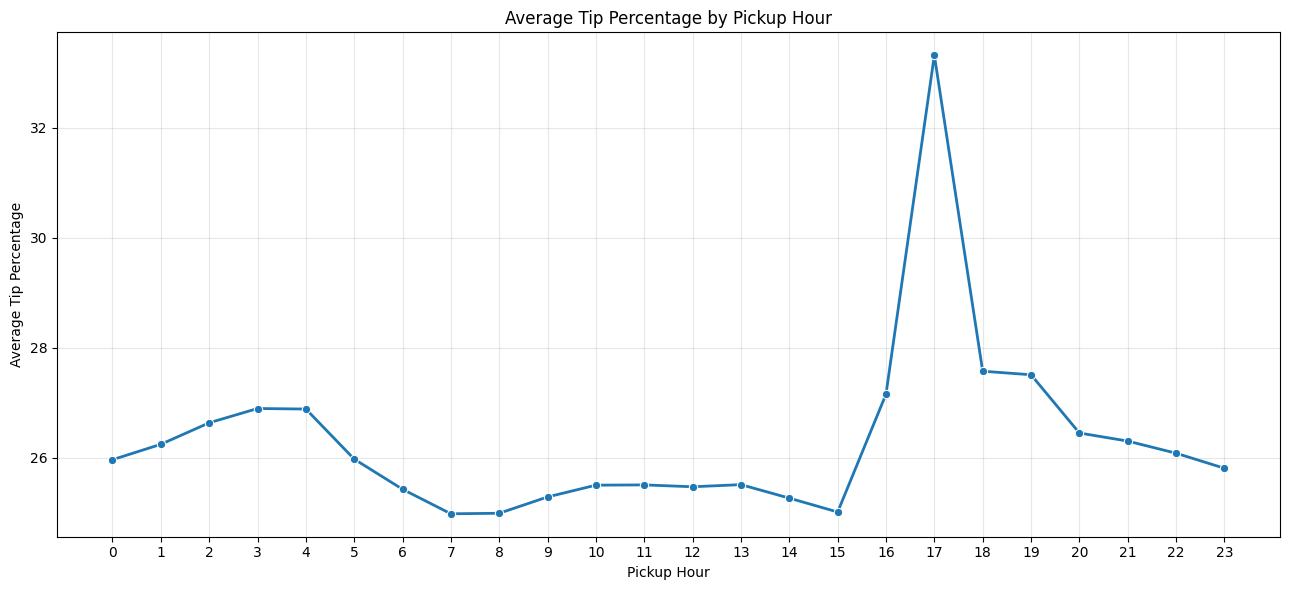

Lowest distance tier: 10+ miles (21.44%)
Lowest passenger count: 2 (25.81%)


,pickup_hour,avg_tip_percentage,median_tip_percentage,trip_count
7,7,24.98%,25.63%,"22,829"
8,8,24.99%,25.37%,"32,370"
15,15,25.01%,25.32%,"51,377"
14,14,25.26%,25.35%,"49,884"
9,9,25.28%,25.63%,"36,109"


In [65]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_tip = df_fin_parameters.copy()

# Keep valid trips
df_analysis = df_tip[
    (df_tip['fare_amount'] > 0) &
    (df_tip['trip_distance'] > 0)
].copy()

# Tip percentage
df_analysis['tip_percentage'] = (
    df_analysis['tip_amount'] /
    df_analysis['fare_amount'] * 100
)

# Pickup hour
df_analysis['pickup_hour'] = (
    df_analysis['tpep_pickup_datetime'].dt.hour
)

# Percentage by distance

df_analysis['distance_tier'] = pd.cut(
    df_analysis['trip_distance'],
    bins=[0, 2, 5, 10, np.inf],
    labels=[
        '0–2 miles',
        '2–5 miles',
        '5–10 miles',
        '10+ miles'
    ]
)

distance_tip = (
    df_analysis
    .groupby('distance_tier', observed=True)
    .agg(
        avg_tip_percentage=('tip_percentage', 'mean'),
        median_tip_percentage=('tip_percentage', 'median'),
        trip_count=('tip_percentage', 'size')
    )
    .reset_index()
)

display(
    distance_tip.style.format({
        'avg_tip_percentage': '{:.2f}%',
        'median_tip_percentage': '{:.2f}%',
        'trip_count': '{:,.0f}'
    })
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=distance_tip,
    x='distance_tier',
    y='avg_tip_percentage',
    color='steelblue'
)

plt.title('Average Tip Percentage by Trip Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Average Tip Percentage')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Tip by passenger count

passenger_tip = (
    df_analysis
    .groupby('passenger_count')
    .agg(
        avg_tip_percentage=('tip_percentage', 'mean'),
        median_tip_percentage=('tip_percentage', 'median'),
        trip_count=('tip_percentage', 'size')
    )
    .reset_index()
    .sort_values('passenger_count')
)

display(
    passenger_tip.style.format({
        'avg_tip_percentage': '{:.2f}%',
        'median_tip_percentage': '{:.2f}%',
        'trip_count': '{:,.0f}'
    })
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=passenger_tip,
    x='passenger_count',
    y='avg_tip_percentage',
    color='darkorange'
)

plt.title('Average Tip Percentage by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Average Tip Percentage')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Tip by pickup hour
hourly_tip = (
    df_analysis
    .groupby('pickup_hour')
    .agg(
        avg_tip_percentage=('tip_percentage', 'mean'),
        median_tip_percentage=('tip_percentage', 'median'),
        trip_count=('tip_percentage', 'size')
    )
    .reset_index()
    .sort_values('pickup_hour')
)

display(
    hourly_tip.style.format({
        'avg_tip_percentage': '{:.2f}%',
        'median_tip_percentage': '{:.2f}%',
        'trip_count': '{:,.0f}'
    })
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=hourly_tip,
    x='pickup_hour',
    y='avg_tip_percentage',
    marker='o',
    linewidth=2
)

plt.title('Average Tip Percentage by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Tip Percentage')
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Reason for lower tips
lowest_distance = distance_tip.loc[
    distance_tip['avg_tip_percentage'].idxmin()
]

print(
    f"Lowest distance tier: {lowest_distance['distance_tier']} "
    f"({lowest_distance['avg_tip_percentage']:.2f}%)"
)

lowest_passengers = passenger_tip.loc[
    passenger_tip['avg_tip_percentage'].idxmin()
]

print(
    f"Lowest passenger count: {int(lowest_passengers['passenger_count'])} "
    f"({lowest_passengers['avg_tip_percentage']:.2f}%)"
)

lowest_hours = (
    hourly_tip
    .sort_values('avg_tip_percentage')
    .head(5)
)

display(
    lowest_hours.style.format({
        'avg_tip_percentage': '{:.2f}%',
        'median_tip_percentage': '{:.2f}%',
        'trip_count': '{:,.0f}'
    })
)


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

Low-tip trips: 45704
High-tip trips: 488481


,Low Tip (<10%),High Tip (>25%)
Average Tip %,6.72,32.84
Average Trip Distance,4.91,2.30
Average Fare,26.45,14.40
Average Passenger Count,1.37,1.36
Average Trip Duration,22.50,12.71


,distance_tier,tip_group,trip_count,group_percentage
0,0–2 miles,High Tip (>25%),"342,144",70.04%
1,0–2 miles,Low Tip (<10%),"15,799",34.57%
2,2–5 miles,High Tip (>25%),"104,365",21.37%
3,2–5 miles,Low Tip (<10%),"17,804",38.96%
4,5–10 miles,High Tip (>25%),"23,758",4.86%
5,5–10 miles,Low Tip (<10%),"5,937",12.99%
6,10+ miles,High Tip (>25%),"18,214",3.73%
7,10+ miles,Low Tip (<10%),"6,164",13.49%


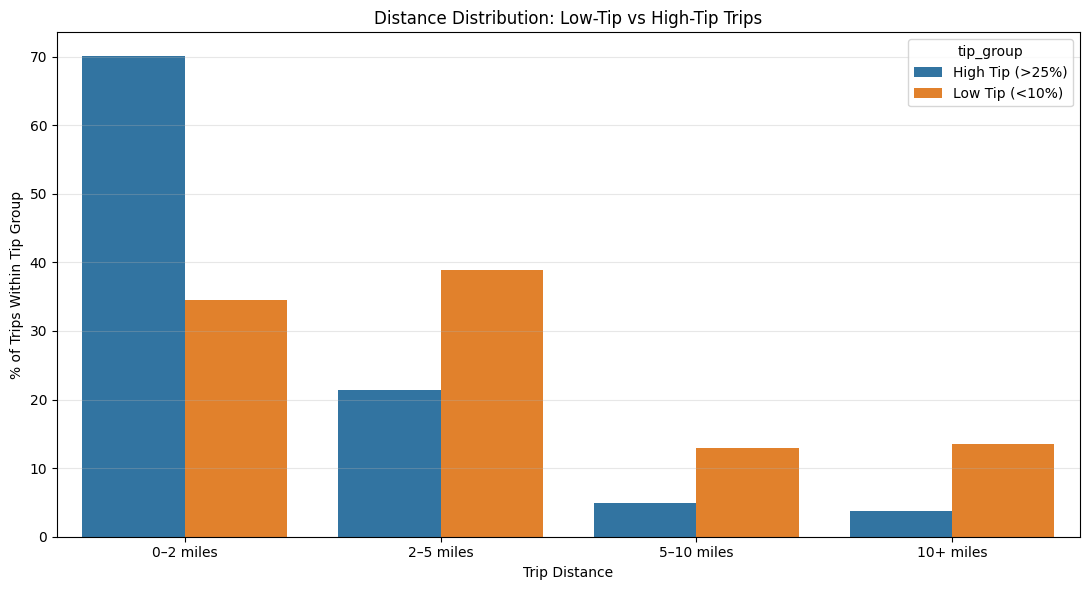

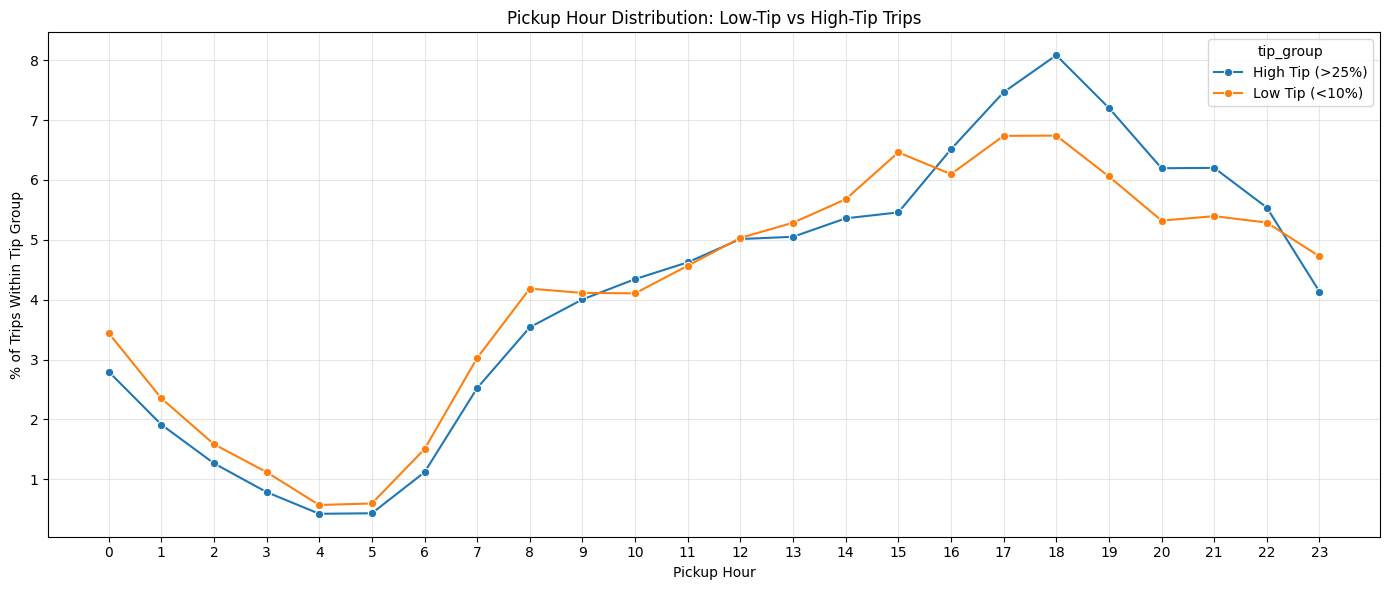

,passenger_count,tip_group,trip_count,group_percentage
0,1,High Tip (>25%),382072,78.216348
1,1,Low Tip (<10%),35468,77.603711
2,2,High Tip (>25%),70178,14.366577
3,2,Low Tip (<10%),6734,14.733940
4,3,High Tip (>25%),16913,3.462366
5,3,Low Tip (<10%),1644,3.597059
6,4,High Tip (>25%),8480,1.735994
7,4,Low Tip (<10%),849,1.857605
8,5,High Tip (>25%),6501,1.330860
9,5,Low Tip (<10%),593,1.297479


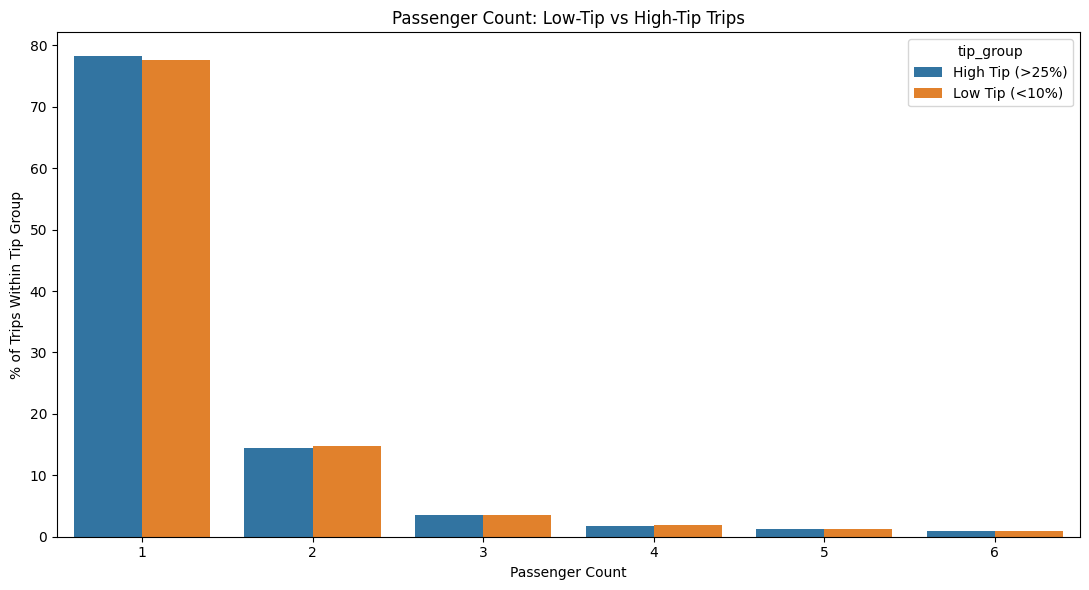

,payment_type,tip_group,trip_count,group_percentage
0,1,High Tip (>25%),488465,99.996725
1,1,Low Tip (<10%),45699,99.989060
2,2,High Tip (>25%),8,0.001638
3,2,Low Tip (<10%),1,0.002188
4,3,High Tip (>25%),2,0.000409
5,3,Low Tip (<10%),3,0.006564
6,4,High Tip (>25%),6,0.001228
7,4,Low Tip (<10%),1,0.002188


In [66]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

# Create groups for tips
df_tips = df_fin_parameters.copy()

# Keep trips where fare is valid
df_analysis = df_tips[
    (df_tips['fare_amount'] > 0) &
    (df_tips['trip_distance'] > 0)
].copy()

# Calculate tip percentage
df_analysis['tip_percentage'] = (
    df_analysis['tip_amount'] /
    df_analysis['fare_amount'] * 100
)

# Create groups
low_tip = df_analysis[
    df_analysis['tip_percentage'] < 10
].copy()

high_tip = df_analysis[
    df_analysis['tip_percentage'] > 25
].copy()

print("Low-tip trips:", len(low_tip))
print("High-tip trips:", len(high_tip))

# Comapre charecterisitics
comparison = pd.DataFrame({
    'Low Tip (<10%)': [
        low_tip['tip_percentage'].mean(),
        low_tip['trip_distance'].mean(),
        low_tip['fare_amount'].mean(),
        low_tip['passenger_count'].mean(),
        low_tip['trip_duration'].mean()
    ],
    'High Tip (>25%)': [
        high_tip['tip_percentage'].mean(),
        high_tip['trip_distance'].mean(),
        high_tip['fare_amount'].mean(),
        high_tip['passenger_count'].mean(),
        high_tip['trip_duration'].mean()
    ]
}, index=[
    'Average Tip %',
    'Average Trip Distance',
    'Average Fare',
    'Average Passenger Count',
    'Average Trip Duration'
])

display(
    comparison.style.format('{:.2f}')
)

# Compare by distance

distance_bins = [0, 2, 5, 10, np.inf]
distance_labels = [
    '0–2 miles',
    '2–5 miles',
    '5–10 miles',
    '10+ miles'
]

df_analysis['distance_tier'] = pd.cut(
    df_analysis['trip_distance'],
    bins=distance_bins,
    labels=distance_labels
)

distance_comparison = (
    df_analysis[
        df_analysis['tip_percentage'].lt(10) |
        df_analysis['tip_percentage'].gt(25)
    ]
    .assign(
        tip_group=lambda x: np.where(
            x['tip_percentage'] < 10,
            'Low Tip (<10%)',
            'High Tip (>25%)'
        )
    )
    .groupby(['distance_tier', 'tip_group'], observed=True)
    .size()
    .reset_index(name='trip_count')
)

# Convert counts to percentages within each tip group
distance_comparison['group_percentage'] = (
    distance_comparison
    .groupby('tip_group')['trip_count']
    .transform(lambda x: x / x.sum() * 100)
)

display(
    distance_comparison.style.format({
        'trip_count': '{:,.0f}',
        'group_percentage': '{:.2f}%'
    })
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=distance_comparison,
    x='distance_tier',
    y='group_percentage',
    hue='tip_group'
)

plt.title('Distance Distribution: Low-Tip vs High-Tip Trips')
plt.xlabel('Trip Distance')
plt.ylabel('% of Trips Within Tip Group')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Compare pickup hours

df_analysis['pickup_hour'] = (
    df_analysis['tpep_pickup_datetime'].dt.hour
)

hour_comparison = (
    df_analysis[
        df_analysis['tip_percentage'].lt(10) |
        df_analysis['tip_percentage'].gt(25)
    ]
    .assign(
        tip_group=lambda x: np.where(
            x['tip_percentage'] < 10,
            'Low Tip (<10%)',
            'High Tip (>25%)'
        )
    )
    .groupby(['pickup_hour', 'tip_group'])
    .size()
    .reset_index(name='trip_count')
)

hour_comparison['group_percentage'] = (
    hour_comparison
    .groupby('tip_group')['trip_count']
    .transform(lambda x: x / x.sum() * 100)
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=hour_comparison,
    x='pickup_hour',
    y='group_percentage',
    hue='tip_group',
    marker='o'
)

plt.title('Pickup Hour Distribution: Low-Tip vs High-Tip Trips')
plt.xlabel('Pickup Hour')
plt.ylabel('% of Trips Within Tip Group')
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Compare passenger count
passenger_comparison = (
    df_analysis[
        df_analysis['tip_percentage'].lt(10) |
        df_analysis['tip_percentage'].gt(25)
    ]
    .assign(
        tip_group=lambda x: np.where(
            x['tip_percentage'] < 10,
            'Low Tip (<10%)',
            'High Tip (>25%)'
        )
    )
    .groupby(['passenger_count', 'tip_group'])
    .size()
    .reset_index(name='trip_count')
)

passenger_comparison['group_percentage'] = (
    passenger_comparison
    .groupby('tip_group')['trip_count']
    .transform(lambda x: x / x.sum() * 100)
)

display(passenger_comparison)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=passenger_comparison,
    x='passenger_count',
    y='group_percentage',
    hue='tip_group'
)

plt.title('Passenger Count: Low-Tip vs High-Tip Trips')
plt.xlabel('Passenger Count')
plt.ylabel('% of Trips Within Tip Group')

plt.tight_layout()
plt.show()

# Compare payment types
payment_comparison = (
    df_analysis[
        df_analysis['tip_percentage'].lt(10) |
        df_analysis['tip_percentage'].gt(25)
    ]
    .assign(
        tip_group=lambda x: np.where(
            x['tip_percentage'] < 10,
            'Low Tip (<10%)',
            'High Tip (>25%)'
        )
    )
    .groupby(['payment_type', 'tip_group'])
    .size()
    .reset_index(name='trip_count')
)

payment_comparison['group_percentage'] = (
    payment_comparison
    .groupby('tip_group')['trip_count']
    .transform(lambda x: x / x.sum() * 100)
)

display(payment_comparison)



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

,pickup_hour,avg_passenger_count,trip_count
0,0,1.43,"24,243"
1,1,1.44,"16,121"
2,2,1.44,"10,455"
3,3,1.45,"6,486"
4,4,1.41,"3,740"
5,5,1.29,"3,955"
6,6,1.25,"10,635"
7,7,1.28,"22,934"
8,8,1.29,"32,516"
9,9,1.30,"36,272"


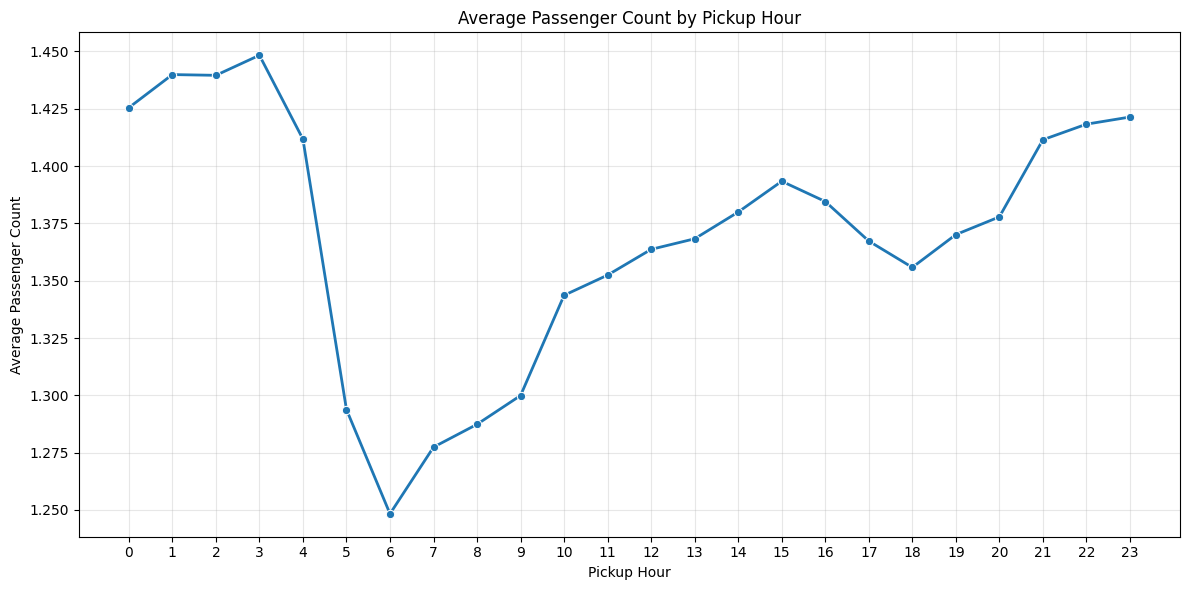

,day_of_week,avg_passenger_count,trip_count
0,Monday,1.34,"105,224"
1,Tuesday,1.32,"124,822"
2,Wednesday,1.31,"133,275"
3,Thursday,1.33,"135,707"
4,Friday,1.39,"125,547"
5,Saturday,1.47,"122,646"
6,Sunday,1.45,"105,582"


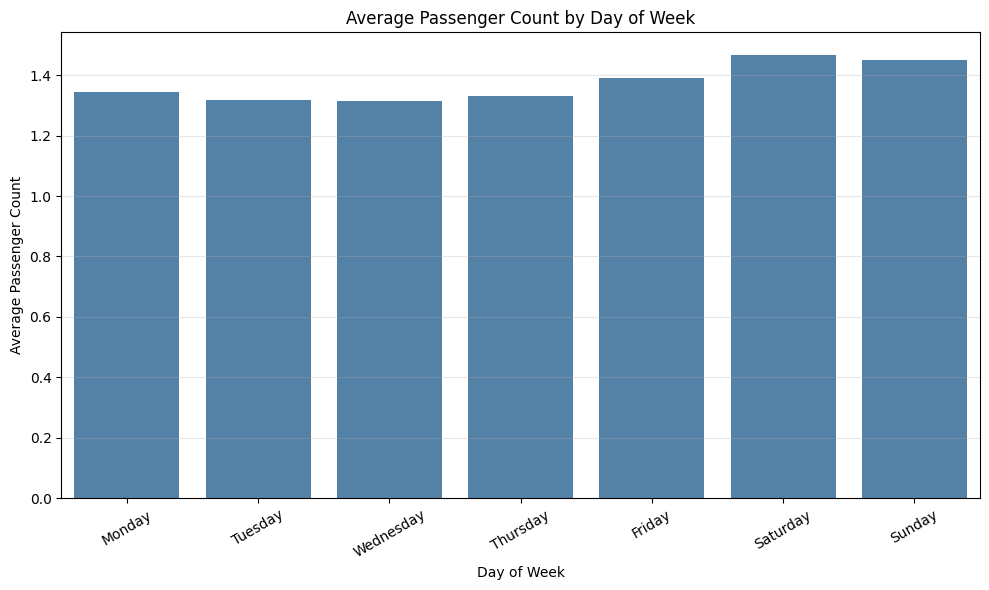

In [67]:
# See how passenger count varies across hours and days

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_cnt = df_fin_parameters.copy()

# Extract pickup hour and day
df_cnt['pickup_hour'] = df_cnt['tpep_pickup_datetime'].dt.hour
df_cnt['day_of_week'] = df_cnt['tpep_pickup_datetime'].dt.day_name()

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Avg passenger cnt by hour

hourly_passengers = (
    df_cnt.groupby('pickup_hour')
      .agg(
          avg_passenger_count=('passenger_count', 'mean'),
          trip_count=('passenger_count', 'size')
      )
      .reset_index()
      .sort_values('pickup_hour')
)

display(
    hourly_passengers.style.format({
        'avg_passenger_count': '{:.2f}',
        'trip_count': '{:,.0f}'
    })
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_passengers,
    x='pickup_hour',
    y='avg_passenger_count',
    marker='o',
    linewidth=2
)

plt.title('Average Passenger Count by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Passenger Count')
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Avg passenger count by day

daily_passengers = (
    df_cnt.groupby('day_of_week')
      .agg(
          avg_passenger_count=('passenger_count', 'mean'),
          trip_count=('passenger_count', 'size')
      )
      .reindex(day_order)
      .reset_index()
)

display(
    daily_passengers.style.format({
        'avg_passenger_count': '{:.2f}',
        'trip_count': '{:,.0f}'
    })
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=daily_passengers,
    x='day_of_week',
    y='avg_passenger_count',
    color='steelblue'
)

plt.title('Average Passenger Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Passenger Count')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

,pu_location_id,zone,borough,avg_passenger_count,total_passengers,trip_count
158,192,Queensboro Hill,Queens,4.00,4,1
147,178,Ocean Parkway South,Brooklyn,3.67,11,3
145,175,Oakland Gardens,Queens,3.33,10,3
72,86,Far Rockaway,Queens,3.00,6,2
3,6,Arrochar/Fort Wadsworth,Staten Island,3.00,3,1
37,47,Claremont/Bathgate,Bronx,3.00,6,2
214,259,Woodlawn/Wakefield,Bronx,2.50,5,2
110,135,Kew Gardens Hills,Queens,2.33,7,3
99,123,Homecrest,Brooklyn,2.33,7,3
90,111,Green-Wood Cemetery,Brooklyn,2.00,2,1


,pu_location_id,zone,borough,avg_passenger_count,total_passengers,trip_count
158,192,Queensboro Hill,Queens,4.00,4,1
147,178,Ocean Parkway South,Brooklyn,3.67,11,3
145,175,Oakland Gardens,Queens,3.33,10,3
72,86,Far Rockaway,Queens,3.00,6,2
3,6,Arrochar/Fort Wadsworth,Staten Island,3.00,3,1
37,47,Claremont/Bathgate,Bronx,3.00,6,2
214,259,Woodlawn/Wakefield,Bronx,2.50,5,2
110,135,Kew Gardens Hills,Queens,2.33,7,3
99,123,Homecrest,Brooklyn,2.33,7,3
90,111,Green-Wood Cemetery,Brooklyn,2.00,2,1


,pu_location_id,zone,borough,avg_passenger_count,total_passengers,trip_count
62,73,East Flushing,Queens,1.00,3,3
68,81,Eastchester,Bronx,1.00,1,1
47,57,nan,nan,1.00,1,1
49,60,Crotona Park East,Bronx,1.00,1,1
138,167,Morrisania/Melrose,Bronx,1.00,4,4
136,165,Midwood,Brooklyn,1.00,3,3
130,159,Melrose South,Bronx,1.00,5,5
95,118,Heartland Village/Todt Hill,Staten Island,1.00,1,1
98,121,Hillcrest/Pomonok,Queens,1.00,8,8
106,131,Jamaica Estates,Queens,1.00,3,3


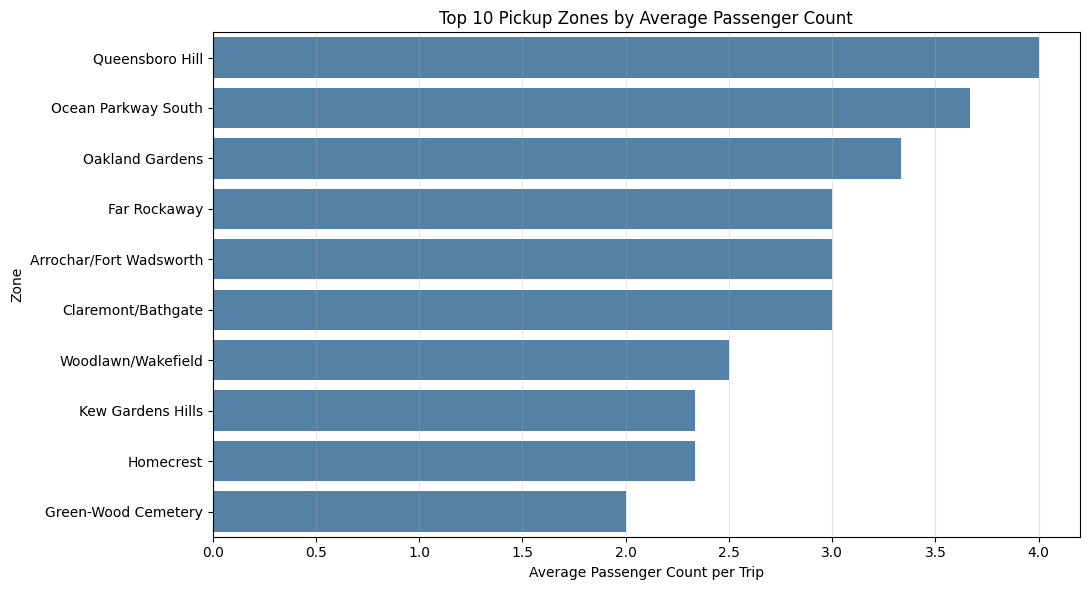

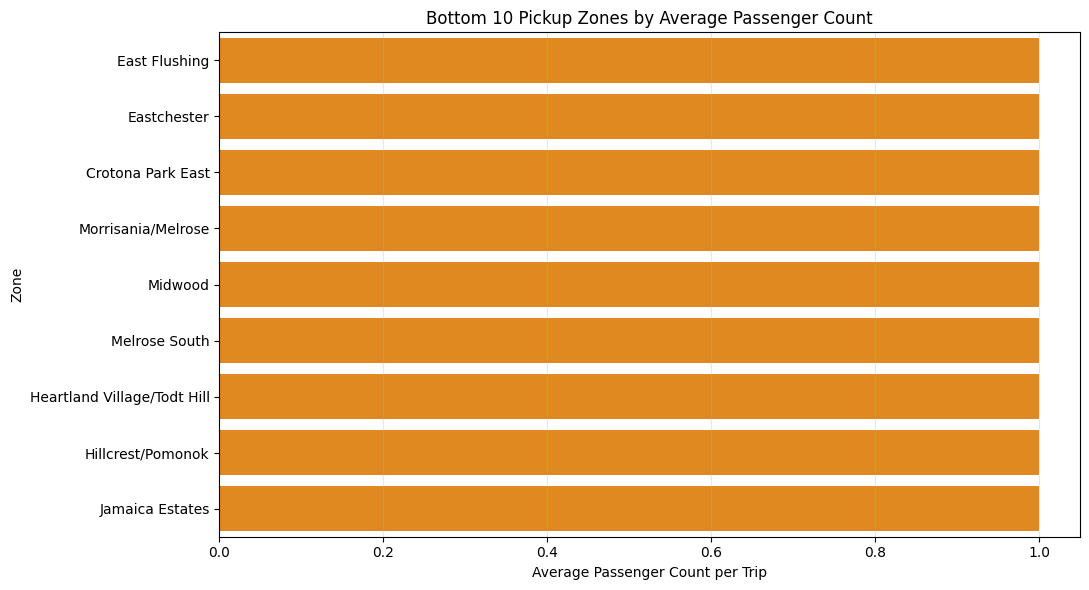

In [68]:
# How does passenger count vary across zones

df_passenger = df_fin_parameters.copy()

zone_passengers = (
    df_passenger.groupby('pu_location_id')
      .agg(
          avg_passenger_count=('passenger_count', 'mean'),
          total_passengers=('passenger_count', 'sum'),
          trip_count=('passenger_count', 'size')
      )
      .reset_index()
)

# Add zone information
zone_passengers = zone_passengers.merge(
    zones[['LocationID', 'zone', 'borough']].drop_duplicates('LocationID'),
    left_on='pu_location_id',
    right_on='LocationID',
    how='left'
)

zone_passengers = zone_passengers[
    [
        'pu_location_id',
        'zone',
        'borough',
        'avg_passenger_count',
        'total_passengers',
        'trip_count'
    ]
]

# Sort

zone_passengers = zone_passengers.sort_values(
    'avg_passenger_count',
    ascending=False
)

display(
    zone_passengers.style.format({
        'avg_passenger_count': '{:.2f}',
        'total_passengers': '{:,.0f}',
        'trip_count': '{:,.0f}'
    })
)

#Top and bottom 10 ones

top_10_zones = (
    zone_passengers
    .sort_values('avg_passenger_count', ascending=False)
    .head(10)
)

display(
    top_10_zones.style.format({
        'avg_passenger_count': '{:.2f}',
        'total_passengers': '{:,.0f}',
        'trip_count': '{:,.0f}'
    })
)

bottom_10_zones = (
    zone_passengers
    .sort_values('avg_passenger_count', ascending=True)
    .head(10)
)

display(
    bottom_10_zones.style.format({
        'avg_passenger_count': '{:.2f}',
        'total_passengers': '{:,.0f}',
        'trip_count': '{:,.0f}'
    })
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_10_zones,
    x='avg_passenger_count',
    y='zone',
    color='steelblue'
)

plt.title('Top 10 Pickup Zones by Average Passenger Count')
plt.xlabel('Average Passenger Count per Trip')
plt.ylabel('Zone')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))

sns.barplot(
    data=bottom_10_zones,
    x='avg_passenger_count',
    y='zone',
    color='darkorange'
)

plt.title('Bottom 10 Pickup Zones by Average Passenger Count')
plt.xlabel('Average Passenger Count per Trip')
plt.ylabel('Zone')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [69]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

# Calculate average passenger count for each pickup location
avg_passengers = (
    df_fin_parameters
    .groupby('pu_location_id')['passenger_count']
    .mean()
)

# Map the averages to zones_with_trips using LocationID
zones_with_trips['avg_passenger_count'] = (
    zones_with_trips['LocationID']
    .map(avg_passengers)
)

# Check the result
display(
    zones_with_trips[
        ['LocationID', 'zone', 'borough', 'avg_passenger_count']
    ].head(10)
)


,LocationID,zone,borough,avg_passenger_count
0,141.0,Lenox Hill West,Manhattan,1.331779
1,161.0,Midtown Center,Manhattan,1.361051
2,246.0,West Chelsea/Hudson Yards,Manhattan,1.400643
3,79.0,East Village,Manhattan,1.399743
4,79.0,East Village,Manhattan,1.399743
5,132.0,JFK Airport,Queens,1.484432
6,148.0,Lower East Side,Manhattan,1.464033
7,79.0,East Village,Manhattan,1.399743
8,90.0,Flatiron,Manhattan,1.346199
9,142.0,Lincoln Square East,Manhattan,1.377611


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

,pickup_hour,total_trips,extra_charge_trips,avg_extra,extra_charge_rate
2,2,"10,329","10,202",$1.59,98.77%
3,3,"6,407","6,292",$1.60,98.21%
1,1,"15,939","15,572",$1.57,97.70%
21,21,"50,301","48,782",$1.75,96.98%
22,22,"46,185","44,663",$1.72,96.70%
0,0,"24,021","23,222",$1.68,96.67%
23,23,"35,554","34,324",$1.81,96.54%
20,20,"49,839","47,833",$1.83,95.98%
4,4,"3,674","3,436",$1.85,93.52%
5,5,"3,915","3,420",$1.99,87.36%


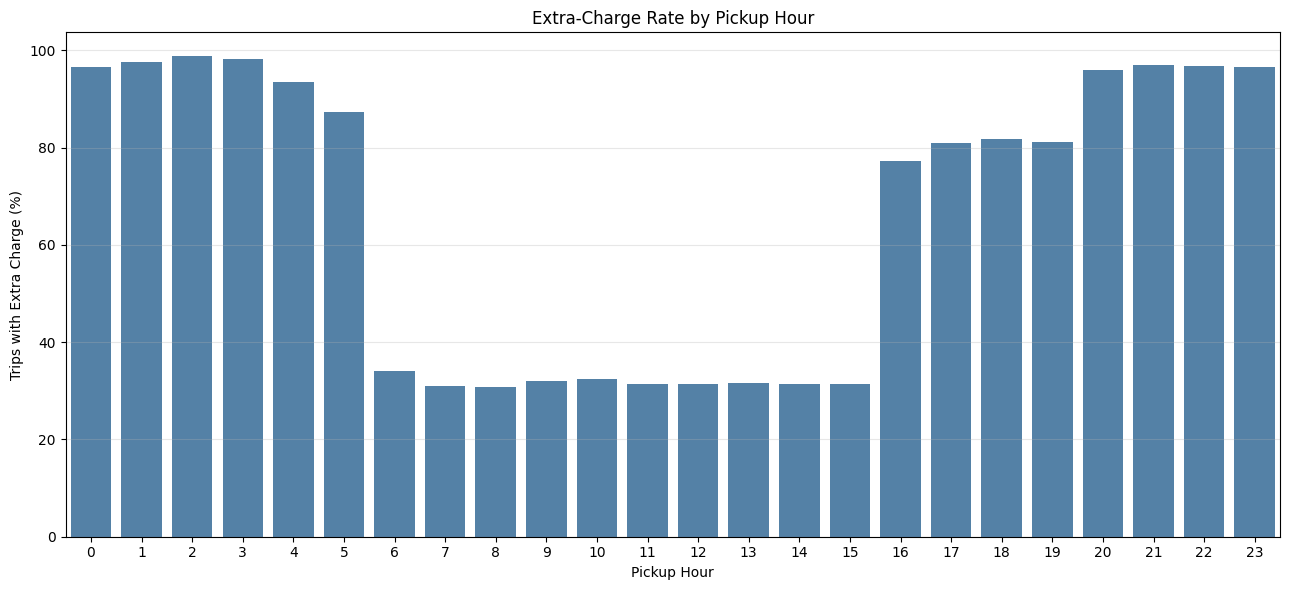

In [70]:
# How often is each surcharge applied?

# Create extra charge data

df_ec = route_data.copy()

df_ec['extra_applied'] = (df_ec['extra'] > 0).astype(int)

df_ec['pickup_hour'] = df_ec['tpep_pickup_datetime'].dt.hour
df_ec['dropoff_hour'] = df_ec['tpep_dropoff_datetime'].dt.hour

df_ec['pickup_day'] = df_ec['tpep_pickup_datetime'].dt.day_name()
df_ec['dropoff_day'] = df_ec['tpep_dropoff_datetime'].dt.day_name()


hourly_extra = (
    df_ec.groupby('pickup_hour')
      .agg(
          total_trips=('extra_applied', 'size'),
          extra_charge_trips=('extra_applied', 'sum'),
          avg_extra=('extra', 'mean')
      )
      .reset_index()
)

hourly_extra['extra_charge_rate'] = (
    hourly_extra['extra_charge_trips'] /
    hourly_extra['total_trips'] * 100
)

hourly_extra = hourly_extra.sort_values(
    'extra_charge_rate',
    ascending=False
)

display(
    hourly_extra.style.format({
        'total_trips': '{:,.0f}',
        'extra_charge_trips': '{:,.0f}',
        'extra_charge_rate': '{:.2f}%',
        'avg_extra': '${:.2f}'
    })
)

plt.figure(figsize=(13, 6))

sns.barplot(
    data=hourly_extra.sort_values('pickup_hour'),
    x='pickup_hour',
    y='extra_charge_rate',
    color='steelblue'
)

plt.title('Extra-Charge Rate by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Trips with Extra Charge (%)')
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**Pre-position cabs before the 6 PM evening peak**
* Since taxi traffic peaks around 6 PM, increase cab availability.
* Gradually reduce repositioning after the peak as demand declines.

**Use Thursday as a high-demand day**
* Since Thursday has the highest observed taxi traffic, increase the number of strategically positioned cabs on Thursdays.
* Begin repositioning earlier on Thursday, particularly ahead of the evening peak.

**Prepare for higher demand in May**
* May shows the highest overall taxi traffic in your analysis.
* Increase fleet availability and driver coverage during May, particularly around the high-demand evening periods.

**Use different strategies for weekdays and weekends**
* Since weekdays have higher traffic, allocate more vehicles to weekday operations.
* Weekend positioning can be more selective, with vehicles concentrated around zones that actually demonstrate weekend demand rather than using the weekday allocation pattern.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.


**Prioritize JFK Airport, Upper East Side South, and Midtown Centre**
* These are the busiest zones, each recording more than 50,000 trips.
* Maintain a higher baseline of available cabs in these zones because they generate consistently high demand.
* However, avoid simply keeping all available cabs there; use time-of-day demand to determine how many vehicles are required.

**Reduce cab concentration during late evening and early morning**
* Since late evening to early morning are relatively quiet, keeping large numbers of cabs distributed across all zones can lead to excessive idle time.
* Consolidate available cabs into a smaller number of strategically selected zones rather than maintaining uniform coverage.
* Reposition cabs toward areas that continue to generate demand instead of leaving them in low-demand zones.

**Use pickup/dropoff imbalance to reposition cabs**
* A zone with many dropoffs but relatively few pickups can accumulate idle cabs.
* Conversely, a zone with many pickups but relatively few dropoffs can experience shortages.
* Use the pickup/dropoff ratio to identify these imbalances and periodically move idle cabs from oversupplied zones toward undersupplied zones.


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

**FINDINGS and ACTIONS**   

**88% of revenue comes from daytime trips**        
Protect daytime competitiveness; avoid aggressive price increases that could reduce the core revenue base

**Night revenue is only 12%**                      
Use targeted evening/night pricing rather than broad increases                                            

**Sunday has highest fare/mile**                   
Test a modest Sunday premium, especially during high-demand periods                                       

**Vendor 2 performs better on fare/mile**          
Use Vendor 2's pricing as a benchmark and selectively close the gap for Vendor 1                          

**Vendor 2 is strongest for trips ≤2 miles**       
Avoid underpricing short trips; consider a stronger minimum/base fare                                     

**Short trips receive higher tips**                
Preserve affordability and service quality for short trips rather than relying on large fare increases    

**Tips are highest in evenings**                   
Evening customers demonstrate willingness to pay; test moderate peak pricing                              

**Extra charges increase evening → early morning**
Clearly communicate applicable surcharges and incorporate them into pricing decisions                     

**Weekend passenger counts are higher**            
Consider demand-based pricing on high-demand weekend periods                                              |


**SUMMARY**

The strongest opportunity is evening peak pricing. Instead of applying a large blanket surcharge, test a moderate peak premium, in high-demand zones. Since 88% of revenue is generated during daytime, daytime pricing should remain competitive. Make extra charges transparent. Introduce weekedn demand based pricing.
